<a href="https://colab.research.google.com/github/RolandoLopez16/RegresionLinealHV/blob/main/RegresionLinealHV_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal para estimación de productividad de equipos Harvester

Este notebook desarrolla un flujo completo de analítica de datos para estimar la productividad operacional de equipos harvester, medida en `M3/HORA`, a partir de variables operativas, forestales, geográficas, temporales y climáticas. El proceso integra análisis exploratorio, preparación de datos, One-Hot Encoding, regresión lineal, validación cruzada, validación de supuestos, modelos regularizados, optimización bayesiana, interpretabilidad y exportación de resultados para Power BI y Streamlit.

## 1. Configuración inicial del entorno

Se instalan e importan las librerías necesarias bajo versiones compatibles para el análisis exploratorio, integración climática, preparación de datos, modelado, validación, optimización, interpretación y exportación de resultados.


In [1]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL DEL ENTORNO
# ============================================================

import sys
import subprocess

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    paquetes_colab = [
        "numpy==2.0.2",
        "pandas==2.2.2",
        "scipy==1.14.1",
        "scikit-learn==1.6.1",
        "statsmodels==0.14.4",
        "matplotlib==3.10.0",
        "seaborn==0.13.2",
        "openpyxl==3.1.5",
        "joblib==1.4.2",
        "requests==2.32.3",
        "tqdm==4.67.1",
        "dython==0.7.8",
        "optuna==4.2.1",
        "meteostat==1.6.8",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *paquetes_colab])

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime
import json
import math
import os
import re
import time
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import scipy

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except Exception:
    root_mean_squared_error = None

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib
import requests

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception:
    optuna = None

try:
    from dython.nominal import associations
except Exception:
    associations = None

try:
    from meteostat import Point, Hourly
except Exception:
    Point, Hourly = None, None

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
ARTIFACTS_DIR = Path("artifacts")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

versions_summary = pd.DataFrame({
    "libreria": ["numpy", "pandas", "scipy", "scikit-learn", "statsmodels", "seaborn"],
    "version": [
        np.__version__,
        pd.__version__,
        scipy.__version__,
        __import__("sklearn").__version__,
        sm.__version__,
        sns.__version__,
    ]
})

print("Entorno configurado correctamente.")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
display(versions_summary)



Entorno configurado correctamente.
Fecha de ejecución: 2026-05-21 05:48:00


,libreria,version
0,numpy,2.0.2
1,pandas,2.2.2
2,scipy,1.14.1
3,scikit-learn,1.6.1
4,statsmodels,0.14.4
5,seaborn,0.13.2


## 2. Módulo auxiliar para artifacts de Streamlit

Se crea un módulo auxiliar con transformadores reutilizables. Esto permite que el pipeline exportado pueda cargarse posteriormente en una aplicación Streamlit sin perder las clases personalizadas utilizadas durante el preprocesamiento.

In [2]:
# ============================================================
# 2. MÓDULO AUXILIAR PARA ARTIFACTS DE STREAMLIT
# ============================================================

TRANSFORMERS_MODULE_PATH = ARTIFACTS_DIR / "hv_transformers.py"

TRANSFORMERS_MODULE_PATH.write_text(
r"""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_bounds_ = X_df.quantile(self.lower_quantile, numeric_only=True)
        self.upper_bounds_ = X_df.quantile(self.upper_quantile, numeric_only=True)
        self.feature_names_in_ = np.array(X_df.columns.astype(str))
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_.index:
                X_df[col] = X_df[col].clip(
                    lower=self.lower_bounds_[col],
                    upper=self.upper_bounds_[col]
                )
        return X_df.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_in_
        return np.array(input_features, dtype=object)
""",
encoding="utf-8"
)

sys.path.insert(0, str(ARTIFACTS_DIR.resolve()))
from hv_transformers import QuantileClipper

print(f"Módulo auxiliar creado en: {TRANSFORMERS_MODULE_PATH}")

Módulo auxiliar creado en: artifacts/hv_transformers.py


## 3. Carga robusta del dataset

Se carga el archivo Excel desde diferentes rutas posibles de ejecución. El proceso permite trabajar en entorno local, en `/mnt/data`, en Google Colab o mediante carga manual del archivo.

In [4]:
# ============================================================
# 3. CARGA ROBUSTA DEL DATASET
# ============================================================

FILE_NAME = "Dataset_HV_2026_v5.xlsx"
SHEET_NAME = "INFORMEHV"

possible_paths = [
    Path("/mnt/data") / FILE_NAME,
    Path("/content") / FILE_NAME,
    Path.cwd() / FILE_NAME,
    Path(".") / FILE_NAME,
    Path("/mnt/data") / "Dataset_HV_2026.xlsx",
    Path("/content") / "Dataset_HV_2026.xlsx",
    Path.cwd() / "Dataset_HV_2026.xlsx",
    Path(".") / "Dataset_HV_2026.xlsx",
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("No se encontró el archivo localmente. Seleccione el archivo Dataset_HV_2026_v5.xlsx.")
        uploaded = files.upload()
        if FILE_NAME in uploaded:
            DATA_PATH = Path("/content") / FILE_NAME
        else:
            DATA_PATH = Path("/content") / next(iter(uploaded.keys()))
    except Exception as exc:
        raise FileNotFoundError(
            f"No se encontró {FILE_NAME}. Coloque el archivo en el mismo directorio del notebook o en /content."
        ) from exc

print(f"Archivo utilizado: {DATA_PATH}")
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")
display(df_raw.head())

No se encontró el archivo localmente. Seleccione el archivo Dataset_HV_2026_v5.xlsx.


Saving Dataset_HV_2026.xlsx to Dataset_HV_2026.xlsx
Archivo utilizado: /content/Dataset_HV_2026.xlsx
Dataset cargado: 1,990 filas x 66 columnas


,Efectividad%,Efectividad% Global,DM%,ARBOLES/HORA,VOLUMEN/ÁRBOL,PRODUCTIVIDAD M3/H,Tiempo Efectivo,Horas disponibles,Total Paradas mecanicas,Mantenimiento periódico,Total Paradas Mecanicas Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5,Unnamed: 64,Unnamed: 65
0,0.8824,0.6250,0.7083,28.5300,0.3100,8.9300,7.5000,8.5000,3.5000,0,0.5000,0.0000,HVPO-4,PONSSE,HAROL OROZCO,4582961,CENTRO,EFAGRAM,2026-01-13,35ALEJA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76°16'08.8''W,4°26'03.0''N,Bolivar,27.3109,Eucalyptus grandis,1.0000,TURNO 1,06:00:00,14:00:00,20,214,67.0000,8.9300,0.0000,18.0000,12.0000,3.0000,NaN,Winche,0.5000,0.2500,0.7500,0.0000,NaN,HUMEDO,4.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.8065,0.3125,0.3875,19.2000,0.1000,2.0000,2.5000,3.1000,4.9000,0,0.3000,0.0000,HVPO-3,PONSSE,Brian Valencia,1022124531,Norte,EFAGRAM,2026-01-02,12PERLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°46'38.6''W,5°21'05.1''N,Guatica,17.4275,Eucalyptus grandis,2.0000,TURNO 2,14:00:00,22:00:00,35,48,5.0000,2.0000,9.0000,16.0000,8.0000,4.6000,Esperando reparación,Winche,0.3000,0.3000,0.3000,0.0000,"Se procesa madera tumbada por motosierrista, s...",Humedo,5.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.9434,0.8962,0.9500,42.6800,0.2500,10.4700,7.1700,7.6000,0.4000,0,0.2000,0.0000,HVPO-3,PONSSE,Jhon Chaverra,1039884146,NORTE,EFAGRAM,2026-01-20,12PALMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°45'30.2''W,5°22'59.0''N,Guatica,17.4321,Eucalyptus grandis,8.0000,TURNO 1,06:00:00,14:00:00,32,306,75.0500,10.4700,0.0000,19.0000,8.0000,0.2000,En reparación,Winche,0.2000,0.2000,0.2300,8.0000,SE REVISA WINCHE DEL EQUIPO,HUMEDO,0.8300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0000,0.8538,0.8538,16.5400,0.3600,5.9600,6.8300,6.8300,1.1700,0,0.1700,0.0000,HVPO-3,PONSSE,BRIAN VALENCIA,1022124531,NORTE,EFAGRAM,2026-02-01,12ARGEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°44'43.0''W,5°24'09.9''N,Riosucio,16.1293,Pinus tecunumanii,6.0000,TURNO 2,14:00:00,22:00:00,15,113,40.7000,5.9600,0.0000,30.0000,8.0000,1.0000,En reparación,Winche,0.1700,0.0000,0.0000,1.0000,SE INICIA TURNO REALIZANDO AJUSTE AL CABLE DEL...,HUMEDO,1.1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.9717,0.7923,0.8154,21.7500,0.5400,11.7000,5.1500,5.3000,1.2000,0,0.3800,0.0000,HVPO-1,PONSSE,JOHNIER RUIZ,4516297,NORTE,GREEN FOREST,2026-03-08,13SNGER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°52'57.2''W,4°13'34.6''N,Sevilla,35.0868,Pinus tecunumanii,6.0000,TURNO 2,14:00:00,22:00:00,32,112,60.2600,11.7000,36.0000,0.0000,6.5000,0.8200,Esperando reparación,Winche,0.3800,0.0000,0.1500,0.0000,NaN,HUMEDO,1.3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Comprensión inicial del dataset

Se revisa la estructura general del dataset, incluyendo dimensión, tipos de datos, primeras observaciones, valores faltantes, duplicados y periodo de análisis disponible.

In [5]:
# ============================================================
# 4. COMPRENSIÓN INICIAL DEL DATASET
# ============================================================

df = df_raw.copy()

print("Dimensión del dataset:")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

display(pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": [str(df[c].dtype) for c in df.columns],
    "valores_no_nulos": [df[c].notna().sum() for c in df.columns],
    "valores_nulos": [df[c].isna().sum() for c in df.columns],
    "porcentaje_nulos": [df[c].isna().mean() * 100 for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns],
}).sort_values("porcentaje_nulos", ascending=False))

print(f"Registros duplicados completos: {df.duplicated().sum():,}")

if "FECHA" in df.columns:
    fecha_tmp = pd.to_datetime(df["FECHA"], errors="coerce")
    print("Periodo de análisis:")
    print(f"Fecha mínima: {fecha_tmp.min()}")
    print(f"Fecha máxima: {fecha_tmp.max()}")

display(df.describe(include="all").T.head(30))

Dimensión del dataset:
Filas: 1,990
Columnas: 66


,columna,tipo_dato,valores_no_nulos,valores_nulos,porcentaje_nulos,valores_unicos
27,clima_horas_lluvia_dia,float64,0,1990,100.0000,0
26,clima_horas_validas_dia,float64,0,1990,100.0000,0
63,MOTIVO 5,float64,0,1990,100.0000,0
64,Unnamed: 64,float64,0,1990,100.0000,0
25,clima_presion_promedio_dia_hpa,float64,0,1990,100.0000,0
24,clima_viento_promedio_dia_kmh,float64,0,1990,100.0000,0
22,clima_temp_max_dia_c,float64,0,1990,100.0000,0
23,clima_precipitacion_dia_mm,float64,0,1990,100.0000,0
20,clima_temp_promedio_dia_c,float64,0,1990,100.0000,0
21,clima_temp_min_dia_c,float64,0,1990,100.0000,0


Registros duplicados completos: 10
Periodo de análisis:
Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-05-15 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Efectividad%,"1,990.0000",NaN,NaN,NaN,0.7079,0.0000,0.6157,0.8892,0.9434,1.0000,0.3472
Efectividad% Global,"1,986.0000",NaN,NaN,NaN,0.6010,0.0000,0.3750,0.7288,0.8750,1.0000,0.3297
DM%,"1,990.0000",NaN,NaN,NaN,0.7597,0.0000,0.6900,0.9375,0.9625,1.0000,0.3209
ARBOLES/HORA,"1,689.0000",NaN,NaN,NaN,44.8320,0.0000,25.1900,39.8000,57.9800,492.0000,32.5635
VOLUMEN/ÁRBOL,"1,566.0000",NaN,NaN,NaN,0.3483,0.0000,0.2200,0.3100,0.4000,4.2400,0.2522
PRODUCTIVIDAD M3/H,"1,990.0000",NaN,NaN,NaN,11.4980,0.0000,5.1350,10.7650,16.3800,77.3600,9.2734
Tiempo Efectivo,"1,990.0000",NaN,NaN,NaN,4.8483,0.0000,2.9908,5.6700,6.9675,15.2700,2.7990
Horas disponibles,"1,990.0000",NaN,NaN,NaN,6.1293,0.0000,5.2625,7.3300,7.7000,15.8000,2.7579
Total Paradas mecanicas,"1,990.0000",NaN,NaN,NaN,1.9173,0.0000,0.3000,0.5000,2.4300,16.0000,2.6309
Mantenimiento periódico,"1,990.0000",NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 5. Definición de la variable objetivo

Se define `M3/HORA` como variable objetivo del modelo, debido a que representa la productividad final de los equipos harvester expresada en metros cúbicos por hora.

In [6]:
# ============================================================
# 5. DEFINICIÓN DE LA VARIABLE OBJETIVO
# ============================================================

TARGET_COL = "M3/HORA"
DUPLICATE_TARGET_COL = "PRODUCTIVIDAD M3/H"

if TARGET_COL not in df.columns:
    raise ValueError(f"No se encontró la variable objetivo esperada: {TARGET_COL}")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

target_summary = df[TARGET_COL].describe().to_frame(name=TARGET_COL)
display(target_summary)

if DUPLICATE_TARGET_COL in df.columns:
    duplicate_equal_rate = np.isclose(
        pd.to_numeric(df[TARGET_COL], errors="coerce"),
        pd.to_numeric(df[DUPLICATE_TARGET_COL], errors="coerce"),
        equal_nan=True
    ).mean()
    print(f"Coincidencia entre '{TARGET_COL}' y '{DUPLICATE_TARGET_COL}': {duplicate_equal_rate:.2%}")

,M3/HORA
count,"1,990.0000"
mean,11.4980
std,9.2734
min,0.0000
25%,5.1350
50%,10.7650
75%,16.3800
max,77.3600


Coincidencia entre 'M3/HORA' y 'PRODUCTIVIDAD M3/H': 100.00%


## 6. Selección metodológica de variables

Se organizan las variables en grupos analíticos: categóricas, numéricas operativas, temporales, climáticas y variables excluidas del modelo principal por duplicidad, identificación personal, baja utilidad predictiva o posible fuga de información.

In [7]:
# ============================================================
# 6. SELECCIÓN METODOLÓGICA DE VARIABLES
# ============================================================

categorical_features_base = [
    "EQUIPO",
    "MARCA",
    "ZONA",
    "CONTRATISTA",
    "FINCA",
    "Municipio Finca",
    "ESPECIE",
    "TURNO",
    "SUELO",
]

numeric_features_base = [
    "PENDIENTE PROMEDIO FINCA",
    "TOTAL DE ARBOLES",
    "DIAMETRO",
    "T PROGRAMADO",
    "T PARADAS MEC",
    "T Paradas Mec Mantenimiento",
    "HORAS DE OTRAS PARADA",
    "ALISTAMIENTO",
    "TANQUEO",
    "ALIMENTACIÓN",
    "T USO WINCHE",
]

date_features = [
    "MES",
    "DIA_SEMANA",
    "SEMANA_ANIO",
]

climate_features_expected = [
    "clima_temp_promedio_dia_c",
    "clima_temp_min_dia_c",
    "clima_temp_max_dia_c",
    "clima_precipitacion_dia_mm",
    "clima_viento_promedio_dia_kmh",
    "clima_presion_promedio_dia_hpa",
    "clima_horas_validas_dia",
    "clima_horas_lluvia_dia",
]

excluded_from_model = [
    "PRODUCTIVIDAD M3/H",
    "M3",
    "T EFECTIVO",
    "ARB/HORA",
    "FUSTES/HORA",
    "VOL/ÁRBOL",
    "E%",
    "E% Global",
    "DM%",
    "Horas disponibles",
    "Ttal P. mec",
    "CEDULA",
    "OPERADOR",
    "NOVEDADES",
    "ESPECIFICACION PARADA",
    "REF REPUESTO",
    "Mantenimiento periódico",
    "T OTRA PARADA 1",
    "T OTRA PARADA2",
    "T OTRA PARADA3",
    "T OTRA PARADA 4",
    "T OTRA PARADA 5",
    "MOTIVO 1",
    "MOTIVO 2",
    "MOTIVO 3",
    "MOTIVO 4",
    "MOTIVO 5",
    "Unnamed: 64",
    "Unnamed: 65",
    "PENDIENTE",
]

categorical_features = [c for c in categorical_features_base if c in df.columns]
numeric_features = [c for c in numeric_features_base if c in df.columns]
climate_features = [c for c in climate_features_expected if c in df.columns]

feature_groups = pd.DataFrame({
    "grupo": (
        ["Categórica"] * len(categorical_features)
        + ["Numérica operativa"] * len(numeric_features)
        + ["Temporal derivada"] * len(date_features)
        + ["Climática esperada"] * len(climate_features_expected)
        + ["Excluida del modelo"] * len(excluded_from_model)
    ),
    "variable": (
        categorical_features
        + numeric_features
        + date_features
        + climate_features_expected
        + excluded_from_model
    )
})

display(feature_groups)

,grupo,variable
0,Categórica,EQUIPO
1,Categórica,MARCA
2,Categórica,ZONA
3,Categórica,CONTRATISTA
4,Categórica,FINCA
5,Categórica,Municipio Finca
6,Categórica,ESPECIE
7,Categórica,TURNO
8,Categórica,SUELO
9,Numérica operativa,PENDIENTE PROMEDIO FINCA


## 7. Limpieza inicial y estandarización de datos

Se prepara la base para análisis y modelado mediante conversión de tipos, limpieza de categorías textuales, transformación de fechas y validación de variables numéricas.

In [8]:
# ============================================================
# 7. LIMPIEZA INICIAL Y ESTANDARIZACIÓN DE DATOS
# ============================================================

df_clean = df.copy()

def clean_category_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    return value.upper()

if "FECHA" in df_clean.columns:
    df_clean["FECHA"] = pd.to_datetime(df_clean["FECHA"], errors="coerce")

for col in categorical_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_category_value)

for col in numeric_features + [TARGET_COL] + climate_features_expected:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

empty_cols = [c for c in df_clean.columns if df_clean[c].isna().all()]
print("Columnas completamente vacías:")
print(empty_cols)

print("Dimensión posterior a limpieza inicial:")
print(df_clean.shape)

display(df_clean.head())

Columnas completamente vacías:
['clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa', 'clima_horas_validas_dia', 'clima_horas_lluvia_dia', 'MOTIVO 5', 'Unnamed: 64']
Dimensión posterior a limpieza inicial:
(1990, 66)


,Efectividad%,Efectividad% Global,DM%,ARBOLES/HORA,VOLUMEN/ÁRBOL,PRODUCTIVIDAD M3/H,Tiempo Efectivo,Horas disponibles,Total Paradas mecanicas,Mantenimiento periódico,Total Paradas Mecanicas Mantenimiento,Total horas de otras paradas,EQUIPO,MARCA,OPERADOR,CEDULA,ZONA,CONTRATISTA,FECHA,FINCA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,Longitud Sexa finca,Latitud Sexa finca,Municipio Finca,PENDIENTE PROMEDIO FINCA,ESPECIE,LOTE,TURNO,HORA INICIO TURNO,HORA FIN TURNO,PENDIENTE,TOTAL DE ARBOLES,M3,M3/HORA,FUSTES/HORA,DIAMETRO,T PROGRAMADO,T PARADAS MEC,ESPECIFICACION PARADA,REF REPUESTO,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,NOVEDADES,SUELO,HORAS DE OTRAS PARADA,T OTRA PARADA 1,T OTRA PARADA2,T OTRA PARADA3,T OTRA PARADA 4,T OTRA PARADA 5,MOTIVO 1,MOTIVO 2,MOTIVO 3,MOTIVO 4,MOTIVO 5,Unnamed: 64,Unnamed: 65
0,0.8824,0.6250,0.7083,28.5300,0.3100,8.9300,7.5000,8.5000,3.5000,0,0.5000,0.0000,HVPO-4,PONSSE,HAROL OROZCO,4582961,CENTRO,EFAGRAM,2026-01-13,35ALEJA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76°16'08.8''W,4°26'03.0''N,BOLIVAR,27.3109,EUCALYPTUS GRANDIS,1.0000,TURNO 1,06:00:00,14:00:00,20,214,67.0000,8.9300,0.0000,18.0000,12.0000,3.0000,NaN,Winche,0.5000,0.2500,0.7500,0.0000,NaN,HUMEDO,4.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.8065,0.3125,0.3875,19.2000,0.1000,2.0000,2.5000,3.1000,4.9000,0,0.3000,0.0000,HVPO-3,PONSSE,Brian Valencia,1022124531,NORTE,EFAGRAM,2026-01-02,12PERLA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°46'38.6''W,5°21'05.1''N,GUATICA,17.4275,EUCALYPTUS GRANDIS,2.0000,TURNO 2,14:00:00,22:00:00,35,48,5.0000,2.0000,9.0000,16.0000,8.0000,4.6000,Esperando reparación,Winche,0.3000,0.3000,0.3000,0.0000,"Se procesa madera tumbada por motosierrista, s...",HUMEDO,5.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.9434,0.8962,0.9500,42.6800,0.2500,10.4700,7.1700,7.6000,0.4000,0,0.2000,0.0000,HVPO-3,PONSSE,Jhon Chaverra,1039884146,NORTE,EFAGRAM,2026-01-20,12PALMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°45'30.2''W,5°22'59.0''N,GUATICA,17.4321,EUCALYPTUS GRANDIS,8.0000,TURNO 1,06:00:00,14:00:00,32,306,75.0500,10.4700,0.0000,19.0000,8.0000,0.2000,En reparación,Winche,0.2000,0.2000,0.2300,8.0000,SE REVISA WINCHE DEL EQUIPO,HUMEDO,0.8300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0000,0.8538,0.8538,16.5400,0.3600,5.9600,6.8300,6.8300,1.1700,0,0.1700,0.0000,HVPO-3,PONSSE,BRIAN VALENCIA,1022124531,NORTE,EFAGRAM,2026-02-01,12ARGEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°44'43.0''W,5°24'09.9''N,RIOSUCIO,16.1293,PINUS TECUNUMANII,6.0000,TURNO 2,14:00:00,22:00:00,15,113,40.7000,5.9600,0.0000,30.0000,8.0000,1.0000,En reparación,Winche,0.1700,0.0000,0.0000,1.0000,SE INICIA TURNO REALIZANDO AJUSTE AL CABLE DEL...,HUMEDO,1.1700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.9717,0.7923,0.8154,21.7500,0.5400,11.7000,5.1500,5.3000,1.2000,0,0.3800,0.0000,HVPO-1,PONSSE,JOHNIER RUIZ,4516297,NORTE,GREEN FOREST,2026-03-08,13SNGER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75°52'57.2''W,4°13'34.6''N,SEVILLA,35.0868,PINUS TECUNUMANII,6.0000,TURNO 2,14:00:00,22:00:00,32,112,60.2600,11.7000,36.0000,0.0000,6.5000,0.8200,Esperando reparación,Winche,0.3800,0.0000,0.1500,0.0000,NaN,HUMEDO,1.3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Creación de variables temporales

A partir de `FECHA` se construyen variables temporales que permiten analizar patrones mensuales, semanales y por día de la semana dentro de la operación forestal.

In [9]:
# ============================================================
# 8. CREACIÓN DE VARIABLES TEMPORALES
# ============================================================

if "FECHA" not in df_clean.columns:
    raise ValueError("No se encontró la columna FECHA para crear variables temporales.")

df_clean["MES"] = df_clean["FECHA"].dt.month
df_clean["DIA_SEMANA"] = df_clean["FECHA"].dt.dayofweek
df_clean["SEMANA_ANIO"] = df_clean["FECHA"].dt.isocalendar().week.astype("Int64")

display(df_clean[["FECHA", "MES", "DIA_SEMANA", "SEMANA_ANIO"]].head())

print("Cobertura temporal:")
display(df_clean[["FECHA", "MES", "DIA_SEMANA", "SEMANA_ANIO"]].describe(include="all"))

,FECHA,MES,DIA_SEMANA,SEMANA_ANIO
0,2026-01-13,1,1,3
1,2026-01-02,1,4,1
2,2026-01-20,1,1,4
3,2026-02-01,2,6,5
4,2026-03-08,3,6,10


Cobertura temporal:


,FECHA,MES,DIA_SEMANA,SEMANA_ANIO
count,1990,"1,990.0000","1,990.0000","1,990.0000"
mean,2026-03-04 05:05:22.010050304,2.6095,2.9789,9.8905
min,2026-01-01 00:00:00,1.0000,0.0000,1.0000
25%,2026-01-30 00:00:00,1.0000,1.0000,5.0000
50%,2026-03-05 00:00:00,3.0000,3.0000,10.0000
75%,2026-04-03 00:00:00,4.0000,5.0000,14.0000
max,2026-05-15 00:00:00,5.0000,6.0000,20.0000
std,NaN,1.2516,2.0042,5.3040


## 9. Preparación de coordenadas geográficas

Se convierten las coordenadas sexagesimales de las fincas a grados decimales para permitir la integración climática por ubicación y fecha.

In [10]:
# ============================================================
# 9. PREPARACIÓN DE COORDENADAS GEOGRÁFICAS
# ============================================================

LAT_COL = "Latitud Sexa finca"
LON_COL = "Longitud Sexa finca"

def dms_to_decimal(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    s = (
        s.replace("º", "°")
         .replace("”", '"')
         .replace("“", '"')
         .replace("’", "'")
         .replace("''", '"')
    )

    direction_match = re.findall(r"[NSEW]", s)
    direction = direction_match[-1] if direction_match else ""

    nums = re.findall(r"[-+]?\d+(?:\.\d+)?", s)
    if len(nums) >= 3:
        degrees = float(nums[0])
        minutes = float(nums[1])
        seconds = float(nums[2])
        decimal = abs(degrees) + minutes / 60 + seconds / 3600
    elif len(nums) == 1:
        decimal = abs(float(nums[0]))
    else:
        return np.nan

    if direction in ["S", "W"]:
        decimal *= -1

    return decimal

if LAT_COL in df_clean.columns and LON_COL in df_clean.columns:
    df_clean["latitud_decimal"] = df_clean[LAT_COL].apply(dms_to_decimal)
    df_clean["longitud_decimal"] = df_clean[LON_COL].apply(dms_to_decimal)
else:
    df_clean["latitud_decimal"] = np.nan
    df_clean["longitud_decimal"] = np.nan

df_clean["lat_round"] = df_clean["latitud_decimal"].round(5)
df_clean["lon_round"] = df_clean["longitud_decimal"].round(5)
df_clean["FECHA_DIA"] = pd.to_datetime(df_clean["FECHA"]).dt.normalize()

coord_cols = [c for c in ["FINCA", LAT_COL, LON_COL, "latitud_decimal", "longitud_decimal"] if c in df_clean.columns]
display(df_clean[coord_cols].drop_duplicates().head(20))

print("Registros con coordenadas válidas:")
print(df_clean[["latitud_decimal", "longitud_decimal"]].notna().all(axis=1).sum())

,FINCA,Latitud Sexa finca,Longitud Sexa finca,latitud_decimal,longitud_decimal
0,35ALEJA,4°26'03.0''N,76°16'08.8''W,4.4342,-76.2691
1,12PERLA,5°21'05.1''N,75°46'38.6''W,5.3514,-75.7774
2,12PALMA,5°22'59.0''N,75°45'30.2''W,5.3831,-75.7584
3,12ARGEN,5°24'09.9''N,75°44'43.0''W,5.4028,-75.7453
4,13SNGER,4°13'34.6''N,75°52'57.2''W,4.2263,-75.8826
6,15RIEL_,4°50'48.0''N,75°37'12.0''W,4.8467,-75.6200
7,31GRACI,4°04'11.9''N,76°24'26.8''W,4.0700,-76.4074
8,13SINAB,4°06'28.8''N,75°52'33.4''W,4.1080,-75.8759
10,34ESTRE,3°51'37.6''N,76°29'55.3''W,3.8604,-76.4987
11,34BRILL,3°51'56.4''N,76°28'57.7''W,3.8657,-76.4827


Registros con coordenadas válidas:
1990


## 10. Integración de variables climáticas

Se enriquece el dataset con información climática diaria por fecha y ubicación. La fuente principal es Open-Meteo; NASA POWER y Meteostat se incorporan como fuentes alternativas cuando la consulta principal no retorna información suficiente.

In [11]:
# ============================================================
# 10. INTEGRACIÓN DE VARIABLES CLIMÁTICAS
# ============================================================

ENABLE_CLIMATE_ENRICHMENT = True
ENABLE_NASA_POWER_FALLBACK = True
ENABLE_METEOSTAT_FALLBACK = True
FORCE_REFRESH_CLIMATE = False

CLIMATE_CACHE_PATH = OUTPUT_DIR / "clima_harvester_cache.csv"

def _safe_request_json(url, params, timeout=45, max_retries=3, sleep_seconds=1.5):
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=timeout)
            response.raise_for_status()
            return response.json()
        except Exception:
            if attempt == max_retries - 1:
                return None
            time.sleep(sleep_seconds)
    return None

def query_open_meteo_hourly(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": float(lat),
        "longitude": float(lon),
        "start_date": pd.to_datetime(start_date).strftime("%Y-%m-%d"),
        "end_date": pd.to_datetime(end_date).strftime("%Y-%m-%d"),
        "hourly": "temperature_2m,precipitation,wind_speed_10m,pressure_msl",
        "timezone": "auto",
    }

    data = _safe_request_json(url, params)
    if not data or "hourly" not in data or "time" not in data["hourly"]:
        return pd.DataFrame()

    hourly = pd.DataFrame(data["hourly"])
    if hourly.empty:
        return pd.DataFrame()

    hourly["datetime"] = pd.to_datetime(hourly["time"], errors="coerce")
    hourly["FECHA_DIA"] = hourly["datetime"].dt.normalize()

    for c in ["temperature_2m", "precipitation", "wind_speed_10m", "pressure_msl"]:
        if c in hourly.columns:
            hourly[c] = pd.to_numeric(hourly[c], errors="coerce")

    daily = hourly.groupby("FECHA_DIA").agg(
        clima_temp_promedio_dia_c=("temperature_2m", "mean"),
        clima_temp_min_dia_c=("temperature_2m", "min"),
        clima_temp_max_dia_c=("temperature_2m", "max"),
        clima_precipitacion_dia_mm=("precipitation", "sum"),
        clima_viento_promedio_dia_kmh=("wind_speed_10m", "mean"),
        clima_presion_promedio_dia_hpa=("pressure_msl", "mean"),
        clima_horas_validas_dia=("temperature_2m", "count"),
        clima_horas_lluvia_dia=("precipitation", lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()),
    ).reset_index()

    daily["fuente_clima"] = "OPEN_METEO"
    return daily

def query_nasa_power_daily(lat, lon, start_date, end_date):
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,WS2M,PS",
        "community": "AG",
        "longitude": float(lon),
        "latitude": float(lat),
        "start": pd.to_datetime(start_date).strftime("%Y%m%d"),
        "end": pd.to_datetime(end_date).strftime("%Y%m%d"),
        "format": "JSON",
    }

    data = _safe_request_json(url, params)
    try:
        params_data = data["properties"]["parameter"]
    except Exception:
        return pd.DataFrame()

    records = []
    all_dates = sorted(set().union(*[set(v.keys()) for v in params_data.values() if isinstance(v, dict)]))
    for d in all_dates:
        records.append({
            "FECHA_DIA": pd.to_datetime(d, format="%Y%m%d", errors="coerce"),
            "clima_temp_promedio_dia_c": params_data.get("T2M", {}).get(d, np.nan),
            "clima_temp_min_dia_c": params_data.get("T2M_MIN", {}).get(d, np.nan),
            "clima_temp_max_dia_c": params_data.get("T2M_MAX", {}).get(d, np.nan),
            "clima_precipitacion_dia_mm": params_data.get("PRECTOTCORR", {}).get(d, np.nan),
            "clima_viento_promedio_dia_kmh": params_data.get("WS2M", {}).get(d, np.nan),
            "clima_presion_promedio_dia_hpa": params_data.get("PS", {}).get(d, np.nan),
            "clima_horas_validas_dia": 24,
            "clima_horas_lluvia_dia": np.nan,
            "fuente_clima": "NASA_POWER",
        })

    daily = pd.DataFrame(records)
    for col in climate_features_expected:
        if col in daily.columns:
            daily[col] = pd.to_numeric(daily[col], errors="coerce").replace(-999, np.nan)
    return daily

def query_meteostat_hourly(lat, lon, start_date, end_date):
    if Point is None or Hourly is None:
        return pd.DataFrame()

    try:
        point = Point(float(lat), float(lon))
        data = Hourly(
            point,
            pd.to_datetime(start_date).to_pydatetime(),
            pd.to_datetime(end_date).to_pydatetime()
        ).fetch()

        if data.empty:
            return pd.DataFrame()

        hourly = data.reset_index()
        hourly["FECHA_DIA"] = pd.to_datetime(hourly["time"], errors="coerce").dt.normalize()

        daily = hourly.groupby("FECHA_DIA").agg(
            clima_temp_promedio_dia_c=("temp", "mean"),
            clima_temp_min_dia_c=("temp", "min"),
            clima_temp_max_dia_c=("temp", "max"),
            clima_precipitacion_dia_mm=("prcp", "sum"),
            clima_viento_promedio_dia_kmh=("wspd", "mean"),
            clima_presion_promedio_dia_hpa=("pres", "mean"),
            clima_horas_validas_dia=("temp", "count"),
            clima_horas_lluvia_dia=("prcp", lambda x: (pd.to_numeric(x, errors="coerce") > 0).sum()),
        ).reset_index()

        daily["fuente_clima"] = "METEOSTAT"
        return daily
    except Exception:
        return pd.DataFrame()

def build_climate_dataset(df_input):
    required = ["lat_round", "lon_round", "FECHA_DIA"]
    if not all(c in df_input.columns for c in required):
        return pd.DataFrame()

    location_df = (
        df_input.dropna(subset=["lat_round", "lon_round", "FECHA_DIA"])
        .groupby(["lat_round", "lon_round"], as_index=False)
        .agg(fecha_min=("FECHA_DIA", "min"), fecha_max=("FECHA_DIA", "max"))
    )

    print(f"Ubicaciones climáticas a consultar: {len(location_df):,}")

    all_weather = []
    for _, row in location_df.iterrows():
        lat = row["lat_round"]
        lon = row["lon_round"]
        start_date = row["fecha_min"]
        end_date = row["fecha_max"]

        weather = query_open_meteo_hourly(lat, lon, start_date, end_date)

        if weather.empty and ENABLE_NASA_POWER_FALLBACK:
            weather = query_nasa_power_daily(lat, lon, start_date, end_date)

        if weather.empty and ENABLE_METEOSTAT_FALLBACK:
            weather = query_meteostat_hourly(lat, lon, start_date, end_date)

        if not weather.empty:
            weather["lat_round"] = lat
            weather["lon_round"] = lon
            all_weather.append(weather)

    if not all_weather:
        return pd.DataFrame()

    climate_df = pd.concat(all_weather, ignore_index=True)
    return climate_df.drop_duplicates(subset=["lat_round", "lon_round", "FECHA_DIA"])

if ENABLE_CLIMATE_ENRICHMENT:
    if CLIMATE_CACHE_PATH.exists() and not FORCE_REFRESH_CLIMATE:
        climate_data = pd.read_csv(CLIMATE_CACHE_PATH, parse_dates=["FECHA_DIA"])
        print(f"Datos climáticos cargados desde caché: {CLIMATE_CACHE_PATH}")
    else:
        climate_data = build_climate_dataset(df_clean)
        if not climate_data.empty:
            climate_data.to_csv(CLIMATE_CACHE_PATH, index=False, encoding="utf-8-sig")
            print(f"Datos climáticos guardados en caché: {CLIMATE_CACHE_PATH}")
else:
    climate_data = pd.DataFrame()

print("Dimensión de datos climáticos:")
print(climate_data.shape)
display(climate_data.head())

Ubicaciones climáticas a consultar: 45
Datos climáticos guardados en caché: outputs/clima_harvester_cache.csv
Dimensión de datos climáticos:
(1871, 12)


,FECHA_DIA,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia,fuente_clima,lat_round,lon_round
0,2026-01-21,21.9375,18.0000,28.5000,10.3000,5.4125,"1,010.5208",24,17,OPEN_METEO,3.0605,-76.5219
1,2026-01-22,20.5750,19.0000,25.2000,26.6000,4.1000,"1,012.0625",24,20,OPEN_METEO,3.0605,-76.5219
2,2026-01-23,22.0167,18.7000,27.2000,3.5000,4.3958,"1,012.0750",24,11,OPEN_METEO,3.0605,-76.5219
3,2026-01-24,22.0000,18.8000,27.6000,7.7000,3.9417,"1,011.9125",24,16,OPEN_METEO,3.0605,-76.5219
4,2026-01-25,21.7917,18.6000,28.0000,29.7000,4.7250,"1,013.0875",24,18,OPEN_METEO,3.0605,-76.5219


## 11. Validación de calidad de variables climáticas

Se evalúa la cobertura de los datos climáticos integrados, la presencia de valores faltantes y la coherencia general de las variables ambientales disponibles.

In [12]:
# ============================================================
# 11. VALIDACIÓN DE CALIDAD DE VARIABLES CLIMÁTICAS
# ============================================================

for col in climate_features_expected:
    if col not in df_clean.columns:
        df_clean[col] = np.nan

if not climate_data.empty:
    climate_merge = climate_data.copy()

    df_clean = df_clean.merge(
        climate_merge,
        on=["lat_round", "lon_round", "FECHA_DIA"],
        how="left",
        suffixes=("", "_api")
    )

    for col in climate_features_expected:
        api_col = f"{col}_api"
        if api_col in df_clean.columns:
            df_clean[col] = df_clean[col].combine_first(df_clean[api_col])

    if "fuente_clima" not in df_clean.columns and "fuente_clima_api" in df_clean.columns:
        df_clean["fuente_clima"] = df_clean["fuente_clima_api"]
    elif "fuente_clima_api" in df_clean.columns:
        df_clean["fuente_clima"] = df_clean.get("fuente_clima", pd.Series(index=df_clean.index, dtype=object)).combine_first(df_clean["fuente_clima_api"])

    api_cols_to_drop = [c for c in df_clean.columns if c.endswith("_api")]
    df_clean = df_clean.drop(columns=api_cols_to_drop, errors="ignore")

climate_quality = pd.DataFrame({
    "variable": climate_features_expected,
    "valores_no_nulos": [df_clean[c].notna().sum() if c in df_clean.columns else 0 for c in climate_features_expected],
    "porcentaje_cobertura": [df_clean[c].notna().mean() * 100 if c in df_clean.columns else 0 for c in climate_features_expected],
    "minimo": [df_clean[c].min() if c in df_clean.columns and df_clean[c].notna().any() else np.nan for c in climate_features_expected],
    "maximo": [df_clean[c].max() if c in df_clean.columns and df_clean[c].notna().any() else np.nan for c in climate_features_expected],
})

display(climate_quality)

if "fuente_clima" in df_clean.columns:
    display(df_clean["fuente_clima"].value_counts(dropna=False).to_frame("registros"))

,variable,valores_no_nulos,porcentaje_cobertura,minimo,maximo
0,clima_temp_promedio_dia_c,1990,100.0000,12.4750,23.7542
1,clima_temp_min_dia_c,1990,100.0000,7.7000,19.5000
2,clima_temp_max_dia_c,1990,100.0000,14.9000,30.0000
3,clima_precipitacion_dia_mm,1990,100.0000,0.0000,88.1000
4,clima_viento_promedio_dia_kmh,1990,100.0000,1.8583,10.1250
5,clima_presion_promedio_dia_hpa,1990,100.0000,"1,007.8250","1,018.3917"
6,clima_horas_validas_dia,1990,100.0000,24.0000,24.0000
7,clima_horas_lluvia_dia,1990,100.0000,0.0000,24.0000


,registros
fuente_clima,
OPEN_METEO,1990


## 12. Análisis exploratorio general del dataset

Se realiza una exploración descriptiva de la base mediante estadísticas generales, distribución de variables numéricas, frecuencia de variables categóricas y revisión de valores faltantes.

In [13]:
# ============================================================
# 12. ANÁLISIS EXPLORATORIO GENERAL DEL DATASET
# ============================================================

missing_summary = (
    df_clean.isna().sum()
    .to_frame("valores_nulos")
    .assign(porcentaje_nulos=lambda x: x["valores_nulos"] / len(df_clean) * 100)
    .sort_values("porcentaje_nulos", ascending=False)
)

display(missing_summary.head(30))

numeric_cols_all = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_all = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Variables numéricas identificadas: {len(numeric_cols_all)}")
print(f"Variables categóricas identificadas: {len(categorical_cols_all)}")

display(df_clean[numeric_cols_all].describe().T)

category_cardinality = pd.DataFrame({
    "variable": categorical_cols_all,
    "categorias_unicas": [df_clean[c].nunique(dropna=True) for c in categorical_cols_all],
    "valores_no_nulos": [df_clean[c].notna().sum() for c in categorical_cols_all]
}).sort_values("categorias_unicas", ascending=False)

display(category_cardinality)

,valores_nulos,porcentaje_nulos
Unnamed: 64,1990,100.0000
MOTIVO 5,1990,100.0000
MOTIVO 4,1988,99.8995
Unnamed: 65,1987,99.8492
MOTIVO 3,1978,99.3970
T OTRA PARADA 5,1973,99.1457
T OTRA PARADA 4,1970,98.9950
T OTRA PARADA3,1958,98.3920
MOTIVO 2,1868,93.8693
T OTRA PARADA2,1851,93.0151


Variables numéricas identificadas: 51
Variables categóricas identificadas: 22


,count,mean,std,min,25%,50%,75%,max
Efectividad%,"1,990.0000",0.7079,0.3472,0.0000,0.6157,0.8892,0.9434,1.0000
Efectividad% Global,"1,986.0000",0.6010,0.3297,0.0000,0.3750,0.7288,0.8750,1.0000
DM%,"1,990.0000",0.7597,0.3209,0.0000,0.6900,0.9375,0.9625,1.0000
ARBOLES/HORA,"1,689.0000",44.8320,32.5635,0.0000,25.1900,39.8000,57.9800,492.0000
VOLUMEN/ÁRBOL,"1,566.0000",0.3483,0.2522,0.0000,0.2200,0.3100,0.4000,4.2400
PRODUCTIVIDAD M3/H,"1,990.0000",11.4980,9.2734,0.0000,5.1350,10.7650,16.3800,77.3600
Tiempo Efectivo,"1,990.0000",4.8483,2.7990,0.0000,2.9908,5.6700,6.9675,15.2700
Horas disponibles,"1,990.0000",6.1293,2.7579,0.0000,5.2625,7.3300,7.7000,15.8000
Total Paradas mecanicas,"1,990.0000",1.9173,2.6309,0.0000,0.3000,0.5000,2.4300,16.0000
Mantenimiento periódico,"1,990.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,variable,categorias_unicas,valores_no_nulos
15,NOVEDADES,876,1438
14,REF REPUESTO,260,887
17,MOTIVO 1,84,632
6,Longitud Sexa finca,45,1990
5,FINCA,45,1990
7,Latitud Sexa finca,45,1990
2,OPERADOR,41,1990
18,MOTIVO 2,28,122
8,Municipio Finca,13,1990
0,EQUIPO,10,1990


## 13. Análisis de la variable objetivo `M3/HORA`

Se analiza la distribución de la productividad mediante estadísticas descriptivas, histograma, boxplot, asimetría y curtosis para comprender el comportamiento de la variable objetivo.

,métrica,valor
0,conteo,"1,990.0000"
1,media,11.4980
2,mediana,10.7650
3,desviación estándar,9.2734
4,mínimo,0.0000
5,máximo,77.3600
6,asimetría,1.3352
7,curtosis,4.5512


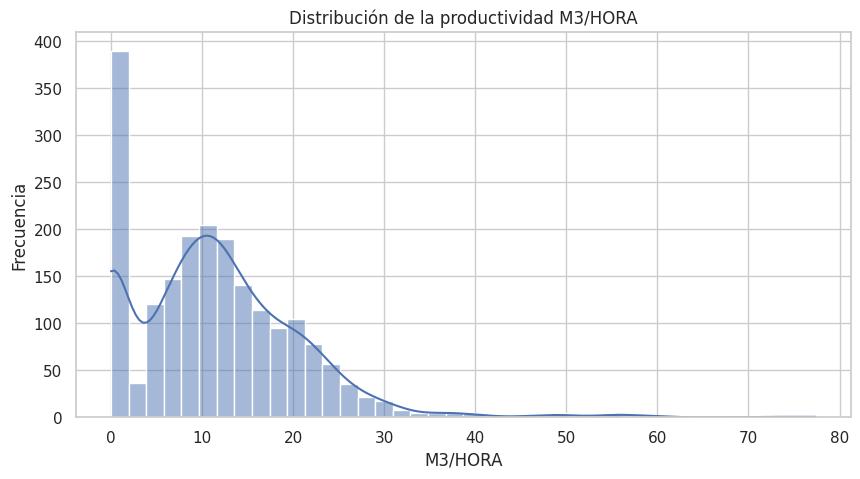

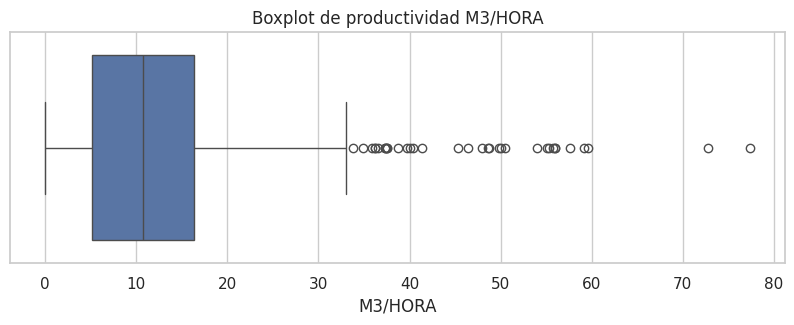

In [14]:
# ============================================================
# 13. ANÁLISIS DE LA VARIABLE OBJETIVO M3/HORA
# ============================================================

target_series = pd.to_numeric(df_clean[TARGET_COL], errors="coerce").dropna()

target_stats = pd.DataFrame({
    "métrica": ["conteo", "media", "mediana", "desviación estándar", "mínimo", "máximo", "asimetría", "curtosis"],
    "valor": [
        target_series.count(),
        target_series.mean(),
        target_series.median(),
        target_series.std(),
        target_series.min(),
        target_series.max(),
        target_series.skew(),
        target_series.kurtosis(),
    ]
})
display(target_stats)

plt.figure(figsize=(10, 5))
sns.histplot(target_series, kde=True, bins=40)
plt.title("Distribución de la productividad M3/HORA")
plt.xlabel("M3/HORA")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10, 3))
sns.boxplot(x=target_series)
plt.title("Boxplot de productividad M3/HORA")
plt.xlabel("M3/HORA")
plt.show()

## 14. Análisis de valores atípicos

Se identifican observaciones extremas mediante rango intercuartílico y percentiles. El análisis permite establecer criterios objetivos para depurar la variable objetivo y revisar variables numéricas relevantes.

,variable,conteo,mínimo,p01,q1,mediana,q3,p99,máximo,límite_iqr_inferior,límite_iqr_superior,outliers_iqr,outliers_p01_p99
0,M3/HORA,1990,0.0000,0.0000,5.1350,10.7650,16.3800,40.4878,77.3600,-11.7325,33.2475,35,20
1,PENDIENTE PROMEDIO FINCA,1990,14.4583,14.4583,17.0946,19.5359,26.4958,35.0868,44.0251,2.9929,40.5975,17,17
2,TOTAL DE ARBOLES,1990,0.0000,0.0000,56.0000,187.0000,308.0000,827.8800,"1,257.0000",-322.0000,686.0000,64,20
3,DIAMETRO,1990,0.0000,0.0000,0.0000,15.0000,20.0000,40.0000,209.0000,-30.0000,50.0000,7,17
4,T PROGRAMADO,1990,0.0000,6.0000,8.0000,8.0000,8.0000,12.0000,16.0000,8.0000,8.0000,392,19
5,T PARADAS MEC,1990,0.0000,0.0000,0.0000,0.0000,2.0000,8.0000,16.0000,-3.0000,5.0000,269,10
6,HORAS DE OTRAS PARADA,1990,0.0000,0.1089,0.9900,2.1667,5.0000,8.0000,16.0000,-5.0250,11.0150,10,33
7,ALISTAMIENTO,1990,0.0000,0.0000,0.1700,0.2700,0.3300,0.8300,8.0000,-0.0700,0.5700,66,18
8,TANQUEO,1990,0.0000,0.0000,0.0000,0.1700,0.2800,0.6700,2.0000,-0.4200,0.7000,18,18
9,ALIMENTACIÓN,1990,0.0000,0.0000,0.0000,0.2300,0.3300,1.0000,1.3300,-0.4950,0.8250,40,7


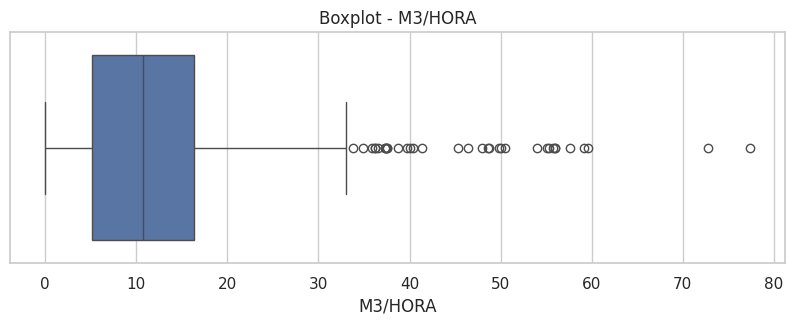

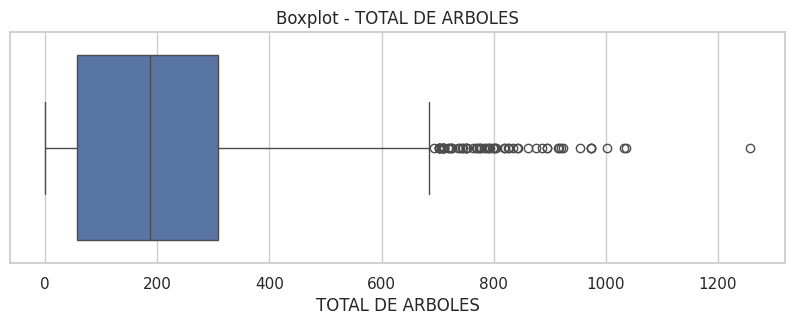

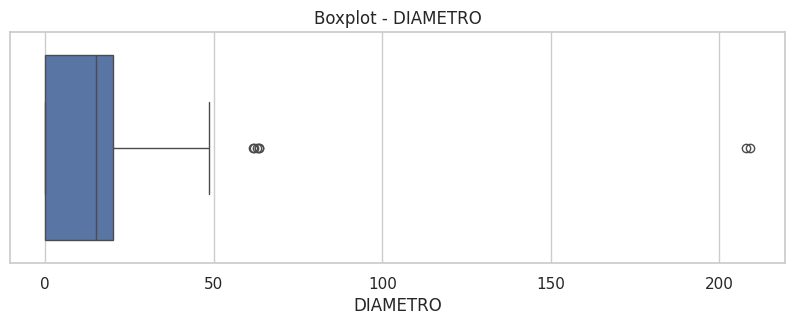

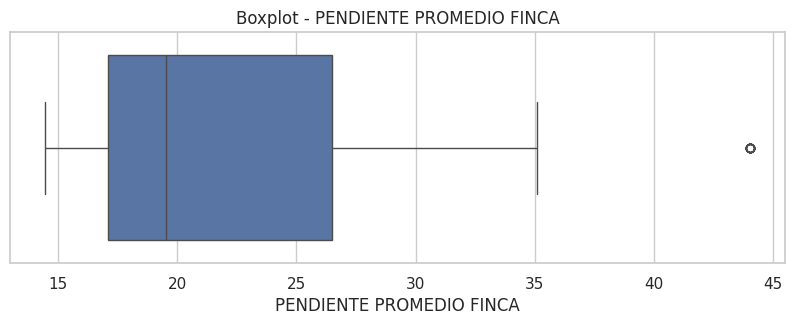

In [15]:
# ============================================================
# 14. ANÁLISIS DE VALORES ATÍPICOS
# ============================================================

def outlier_report(series, name):
    s = pd.to_numeric(series, errors="coerce").dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    p01, p99 = s.quantile([0.01, 0.99])
    return {
        "variable": name,
        "conteo": s.count(),
        "mínimo": s.min(),
        "p01": p01,
        "q1": q1,
        "mediana": s.median(),
        "q3": q3,
        "p99": p99,
        "máximo": s.max(),
        "límite_iqr_inferior": lower_iqr,
        "límite_iqr_superior": upper_iqr,
        "outliers_iqr": ((s < lower_iqr) | (s > upper_iqr)).sum(),
        "outliers_p01_p99": ((s < p01) | (s > p99)).sum(),
    }

outlier_vars = [TARGET_COL] + [c for c in numeric_features if c in df_clean.columns]
outlier_table = pd.DataFrame([outlier_report(df_clean[c], c) for c in outlier_vars])
display(outlier_table)

for col in [TARGET_COL, "TOTAL DE ARBOLES", "DIAMETRO", "PENDIENTE PROMEDIO FINCA"]:
    if col in df_clean.columns:
        plt.figure(figsize=(10, 3))
        sns.boxplot(x=pd.to_numeric(df_clean[col], errors="coerce"))
        plt.title(f"Boxplot - {col}")
        plt.xlabel(col)
        plt.show()

## 15. Análisis de variables numéricas frente a la productividad

Se estudia la relación entre la productividad y las variables numéricas operativas, forestales y climáticas mediante correlaciones, dispersión y líneas de tendencia.

,correlación_con_productividad
TOTAL DE ARBOLES,0.5888
HORAS DE OTRAS PARADA,-0.4296
T PARADAS MEC,-0.3339
DIAMETRO,0.2850
TANQUEO,0.2392
ALIMENTACIÓN,0.2296
ALISTAMIENTO,0.2188
clima_viento_promedio_dia_kmh,0.1433
clima_presion_promedio_dia_hpa,-0.1214
T USO WINCHE,0.0860


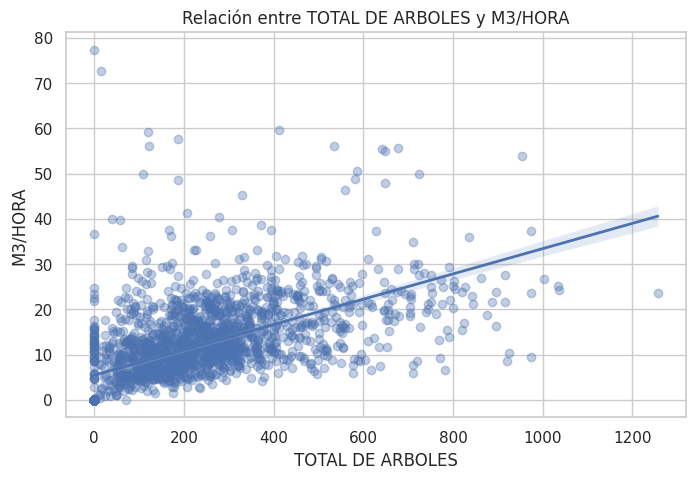

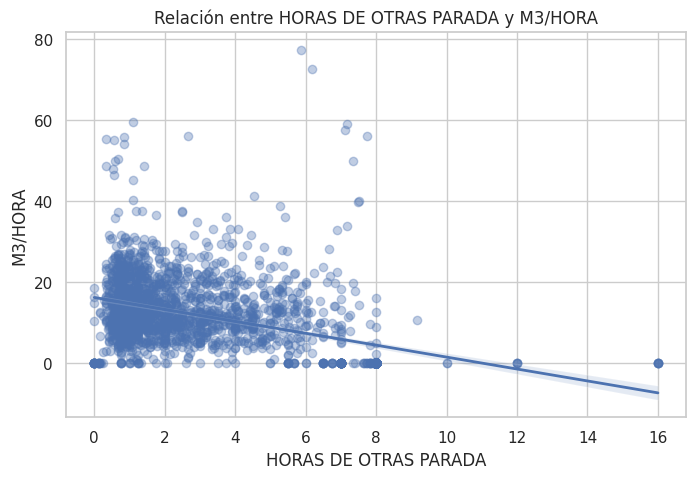

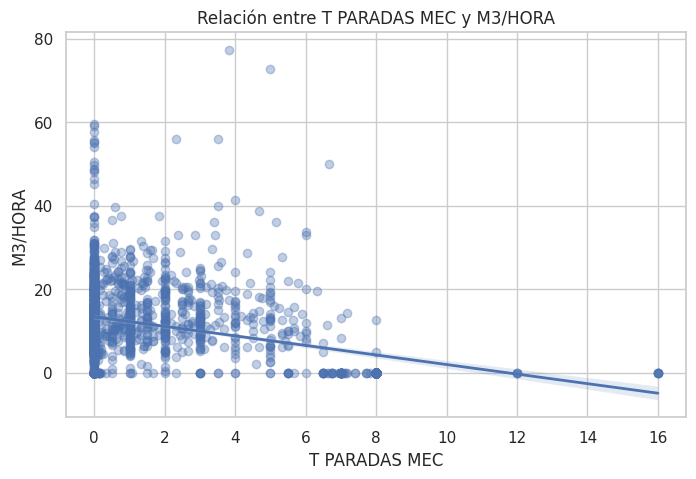

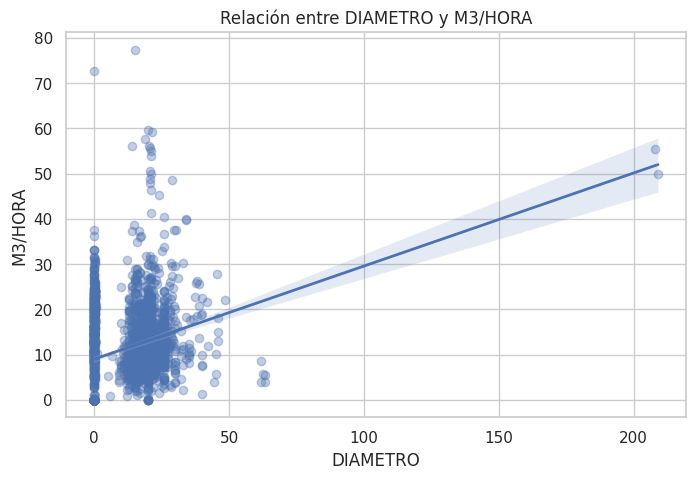

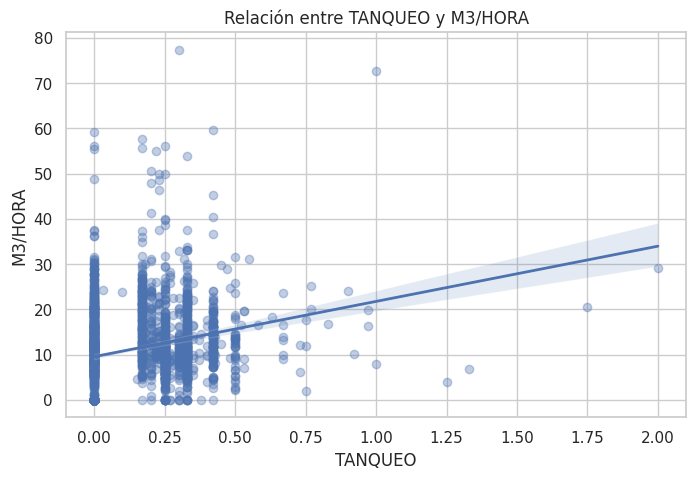

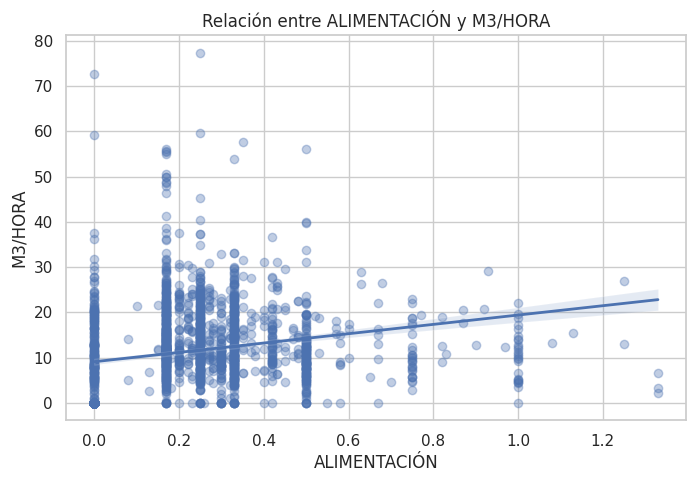

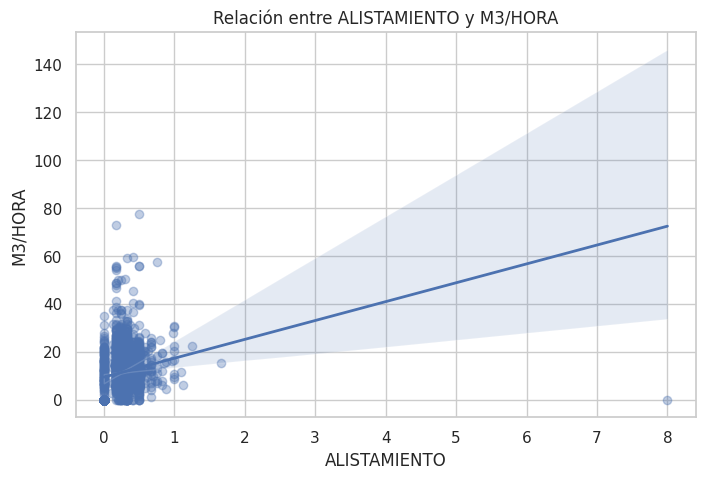

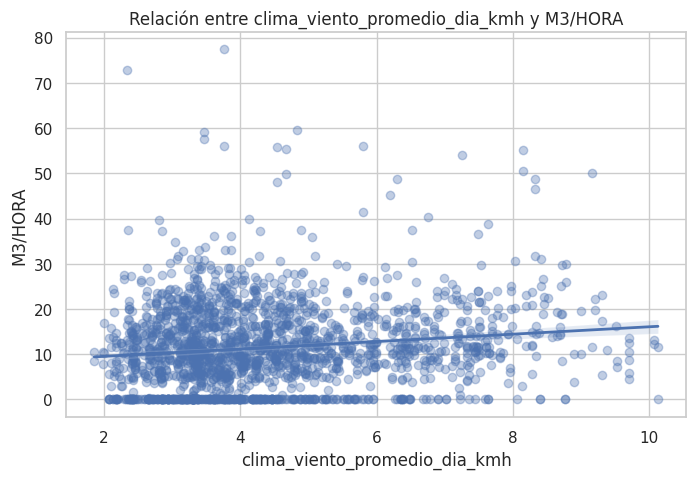

In [16]:
# ============================================================
# 15. ANÁLISIS DE VARIABLES NUMÉRICAS FRENTE A LA PRODUCTIVIDAD
# ============================================================

climate_features_valid_eda = [
    c for c in climate_features_expected
    if c in df_clean.columns and df_clean[c].notna().sum() > 0
]

numeric_eda_features = [c for c in numeric_features + climate_features_valid_eda if c in df_clean.columns]

corr_target = (
    df_clean[[TARGET_COL] + numeric_eda_features]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("correlación_con_productividad")
)

display(corr_target)

top_numeric_for_plots = corr_target.head(8).index.tolist()

for col in top_numeric_for_plots:
    plt.figure(figsize=(8, 5))
    sns.regplot(
        data=df_clean,
        x=col,
        y=TARGET_COL,
        scatter_kws={"alpha": 0.35},
        line_kws={"linewidth": 2}
    )
    plt.title(f"Relación entre {col} y {TARGET_COL}")
    plt.xlabel(col)
    plt.ylabel(TARGET_COL)
    plt.show()

## 16. Análisis de variables categóricas frente a la productividad

Se evalúa la variabilidad de la productividad según las categorías principales de la operación, considerando conteos, promedios, medianas y dispersión.

### Productividad por EQUIPO

,EQUIPO,registros,promedio,mediana,desviacion
4,HVJD-5,271,15.2341,16.9500,9.3084
9,HVPO-5,264,12.8291,13.1500,9.4373
1,HVJD-2,256,14.6860,12.4150,11.3352
3,HVJD-4,178,13.1831,12.2450,10.4753
2,HVJD-3,184,10.0491,9.9950,6.1292
0,HVJD-1,176,9.3902,9.5850,7.2910
8,HVPO-4,143,10.5045,9.3100,8.4536
5,HVPO-1,156,9.0417,8.7150,8.3463
7,HVPO-3,184,8.5843,8.4500,7.2613
6,HVPO-2,178,7.1104,6.5700,7.7652


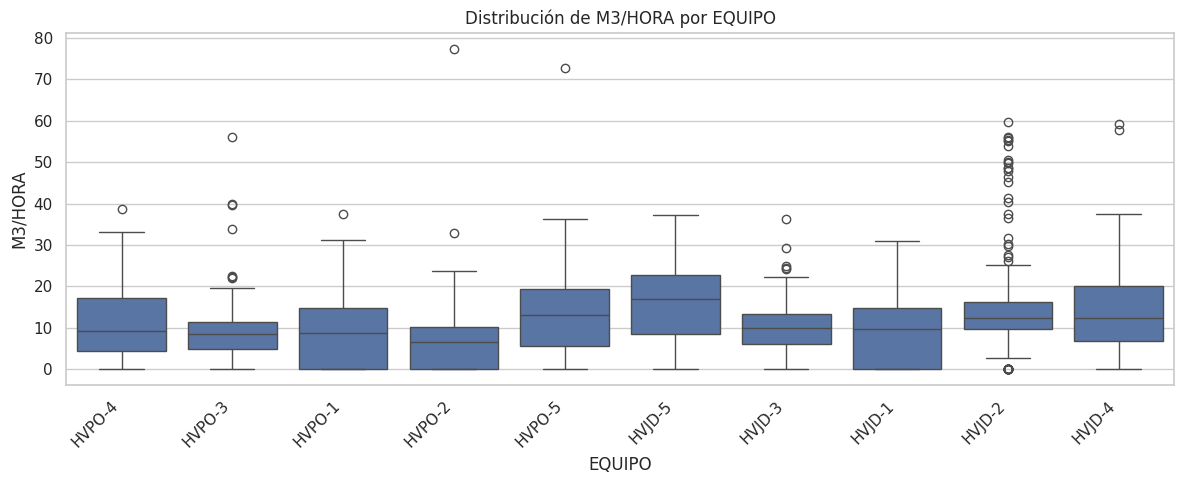

### Productividad por MARCA

,MARCA,registros,promedio,mediana,desviacion
0,JOHN DEER,1065,12.8980,11.8600,9.5839
1,PONSSE,925,9.8862,9.0400,8.6306


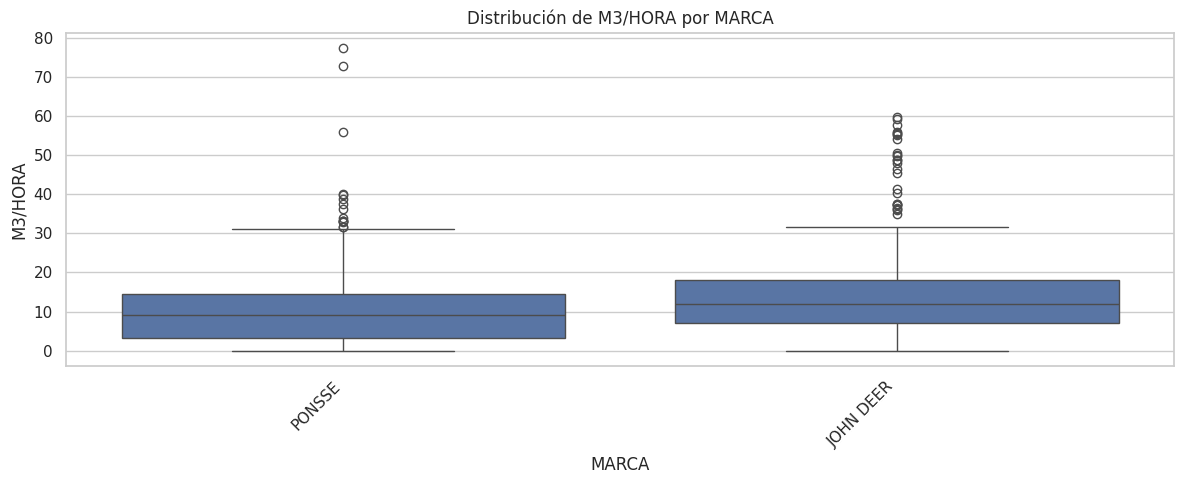

### Productividad por ZONA

,ZONA,registros,promedio,mediana,desviacion
0,CENTRO,1023,12.8747,11.7000,9.7122
2,SUR,147,10.1537,10.7800,7.2158
1,NORTE,820,10.0215,9.1550,8.7741


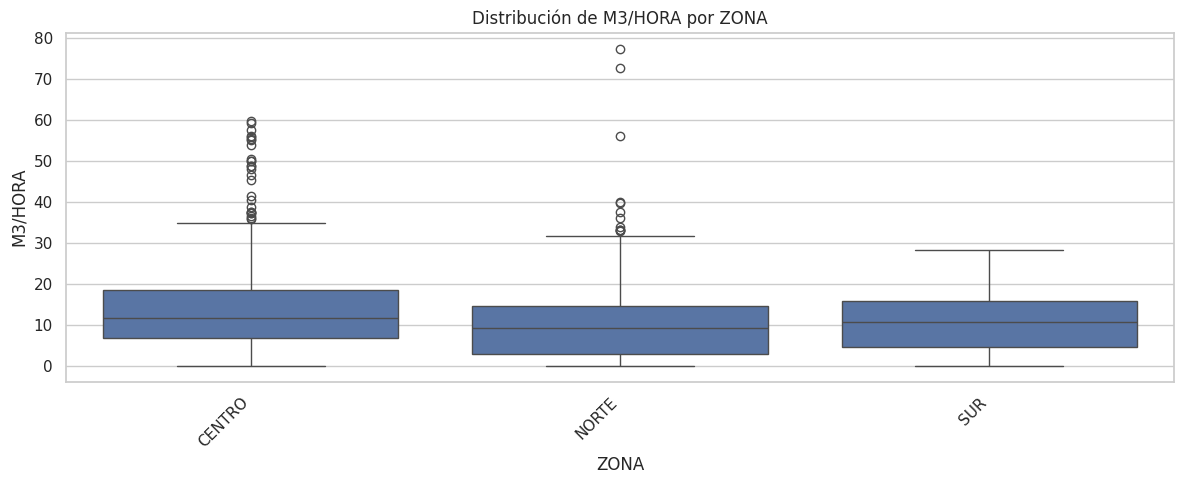

### Productividad por CONTRATISTA

,CONTRATISTA,registros,promedio,mediana,desviacion
2,GREEN FOREST,725,13.1047,13.0600,9.4244
0,AMBAR,398,10.8759,10.2800,9.1367
1,EFAGRAM,867,10.4401,9.6300,9.0294


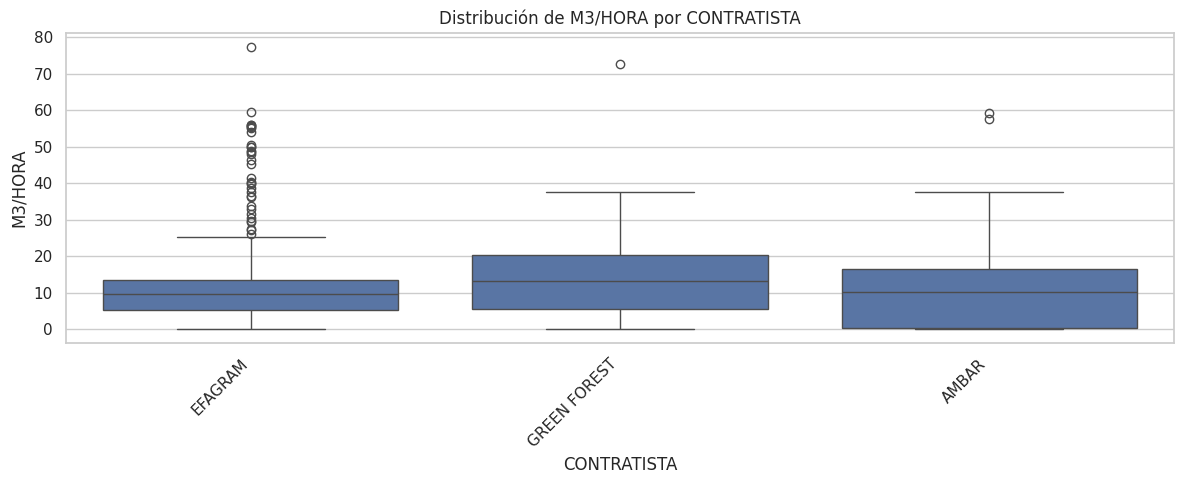

### Productividad por FINCA

,FINCA,registros,promedio,mediana,desviacion
34,34RANCH,4,19.6875,20.7150,16.4076
31,32SNRAF,55,18.2220,20.2500,8.3104
32,34BRILL,31,17.2323,19.5900,10.2836
33,34ESTRE,58,15.5226,19.4900,10.0745
24,32ESMEP,13,15.0862,19.3700,9.4518
19,31ALASK,29,17.7372,18.6200,14.8928
27,32MONTE,39,15.7456,16.3600,8.9653
13,13SINAB,176,14.6645,15.3100,9.1709
38,35CAROL,27,12.4333,14.9000,7.3913
26,32LOREN,2,14.1300,14.1300,3.4648


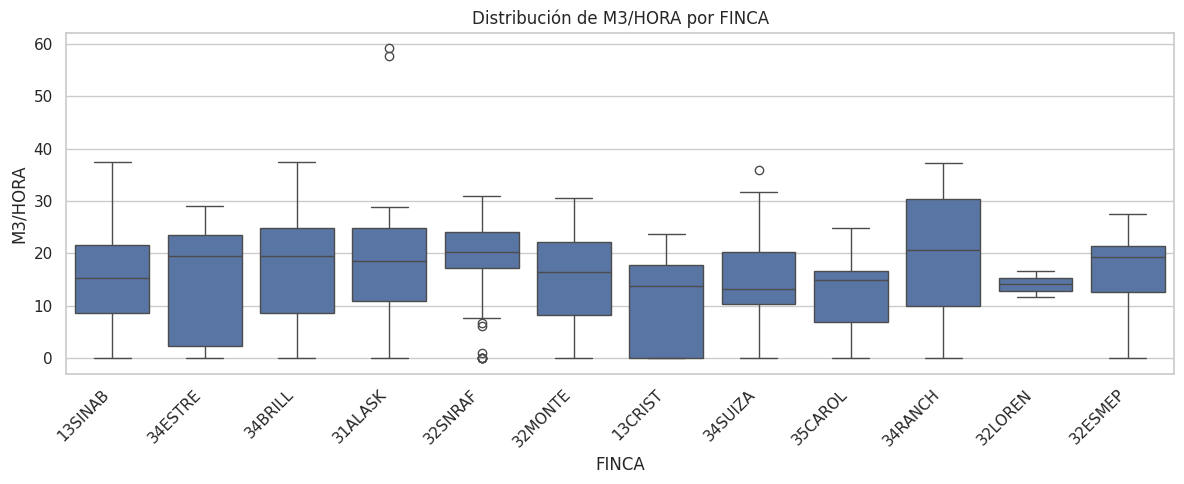

### Productividad por Municipio Finca

,Municipio Finca,registros,promedio,mediana,desviacion
3,DARIEN_CALIMA,31,17.2323,19.5900,10.2836
12,YUMBO,13,15.0862,19.3700,9.4518
11,VIJES,119,15.7180,18.1800,8.7894
5,RESTREPO,93,15.5897,17.4100,10.1758
10,SEVILLA,452,11.8418,12.1300,9.2683
2,CUMBRE,324,13.8020,11.7800,10.6120
8,SANTANDER_QUILICHAO,147,10.1537,10.7800,7.2158
1,CAICEDONIA,2,9.9900,9.9900,14.1280
6,RIOFRIO,238,11.0920,9.7450,10.0943
0,BOLIVAR,205,9.7975,9.6100,6.1498


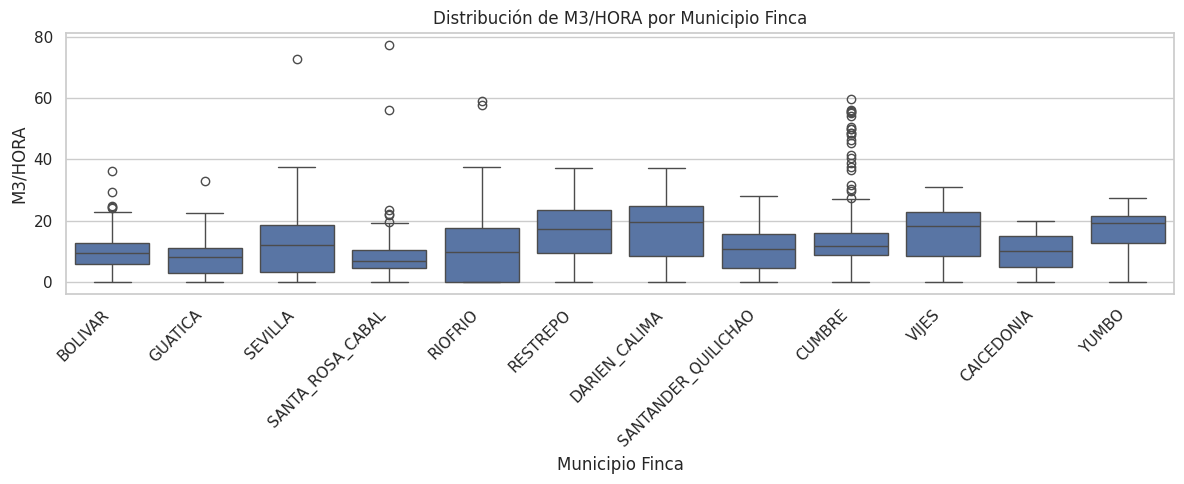

### Productividad por ESPECIE

,ESPECIE,registros,promedio,mediana,desviacion
7,PINUS PATULA,104,16.8055,20.0450,9.8710
1,EUCALIPTO UROGRANDIS,2,18.2650,18.2650,4.0659
6,PINUS MAXIMINOI,186,10.7040,12.5350,7.7618
5,PINUS KESIYA,56,12.6063,11.9700,6.4917
8,PINUS TECUNUMANII,475,12.9523,11.8700,9.1485
4,PINO PATULA,5,10.2340,9.7100,6.5445
3,EUCALYPTUS UROGRANDIS,266,10.4536,9.5550,8.1181
2,EUCALYPTUS GRANDIS,888,10.5444,9.2650,9.7578
0,EUCALIPTO GRANDIS,8,6.5288,4.6950,6.0023


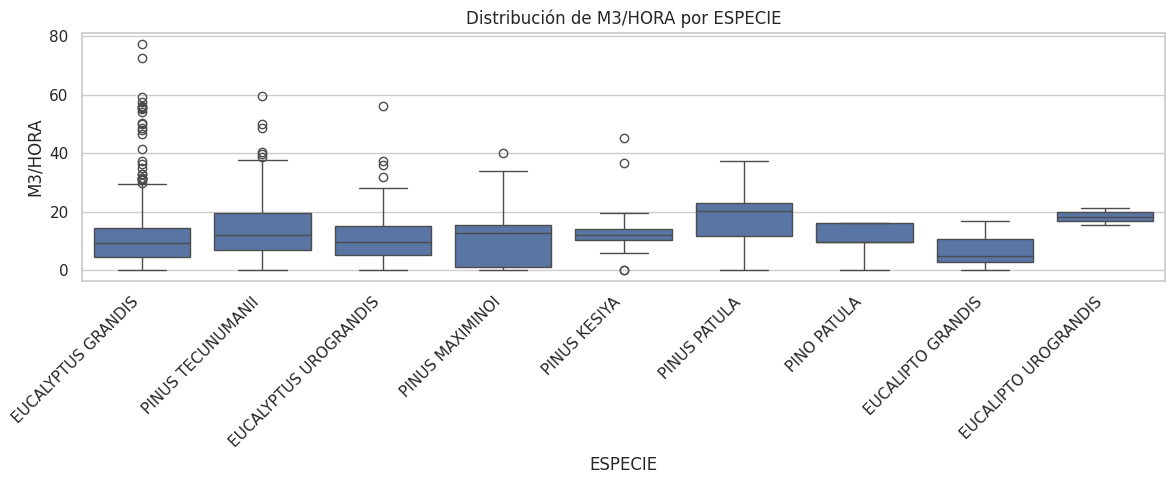

### Productividad por TURNO

,TURNO,registros,promedio,mediana,desviacion
2,TURNO 3,42,11.8521,11.0950,7.1123
0,TURNO 1,1053,11.2817,10.7800,9.0861
1,TURNO 2,895,11.7359,10.5700,9.5782


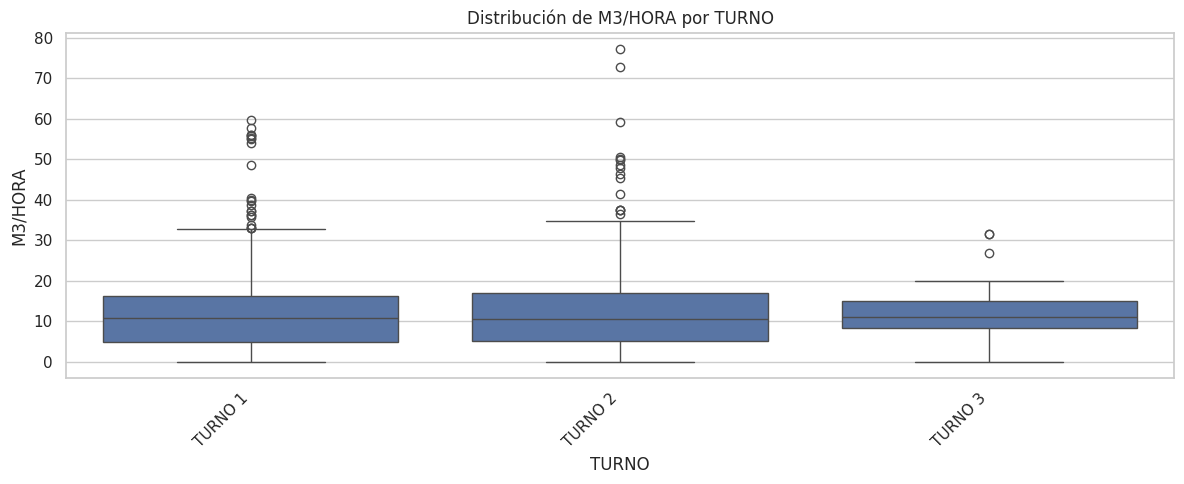

### Productividad por SUELO

,SUELO,registros,promedio,mediana,desviacion
1,SECO,713,13.2278,11.9500,9.8028
0,HUMEDO,1218,10.6884,9.9000,8.7854
2,NaN,59,7.3086,0.0000,9.0279


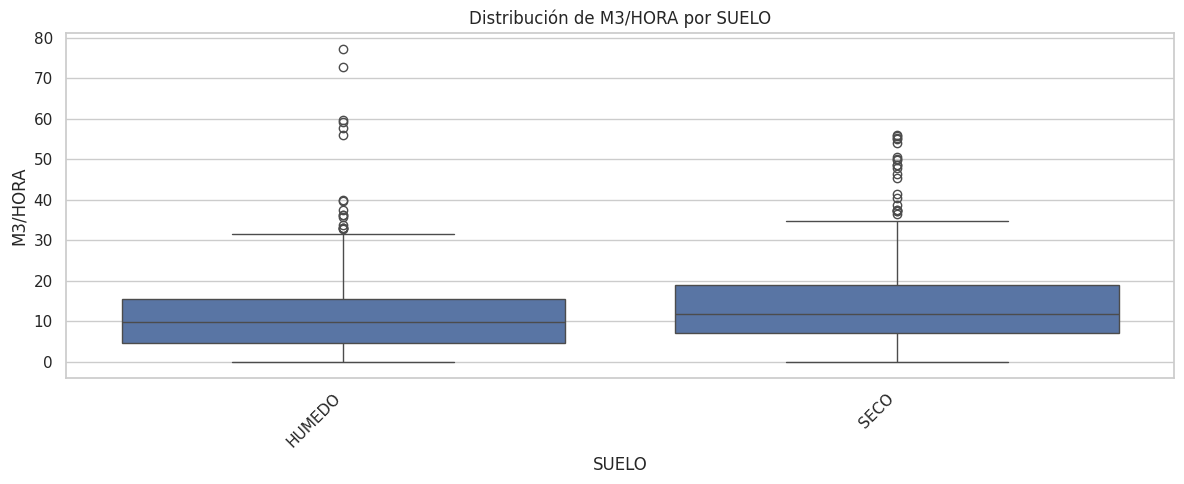

In [17]:
# ============================================================
# 16. ANÁLISIS DE VARIABLES CATEGÓRICAS FRENTE A PRODUCTIVIDAD
# ============================================================

for col in categorical_features:
    if col not in df_clean.columns:
        continue

    summary_cat = (
        df_clean.groupby(col, dropna=False)[TARGET_COL]
        .agg(registros="count", promedio="mean", mediana="median", desviacion="std")
        .reset_index()
        .sort_values("mediana", ascending=False)
    )

    display(Markdown(f"### Productividad por {col}"))
    display(summary_cat.head(15))

    top_categories = summary_cat.head(12)[col].astype(str).tolist()
    df_plot = df_clean[df_clean[col].astype(str).isin(top_categories)].copy()

    if not df_plot.empty:
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=df_plot, x=col, y=TARGET_COL)
        plt.title(f"Distribución de {TARGET_COL} por {col}")
        plt.xlabel(col)
        plt.ylabel(TARGET_COL)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## 17. Matriz de correlación entre variables numéricas

Se construye una matriz de correlación para identificar relaciones lineales entre variables numéricas y posibles redundancias entre predictores.

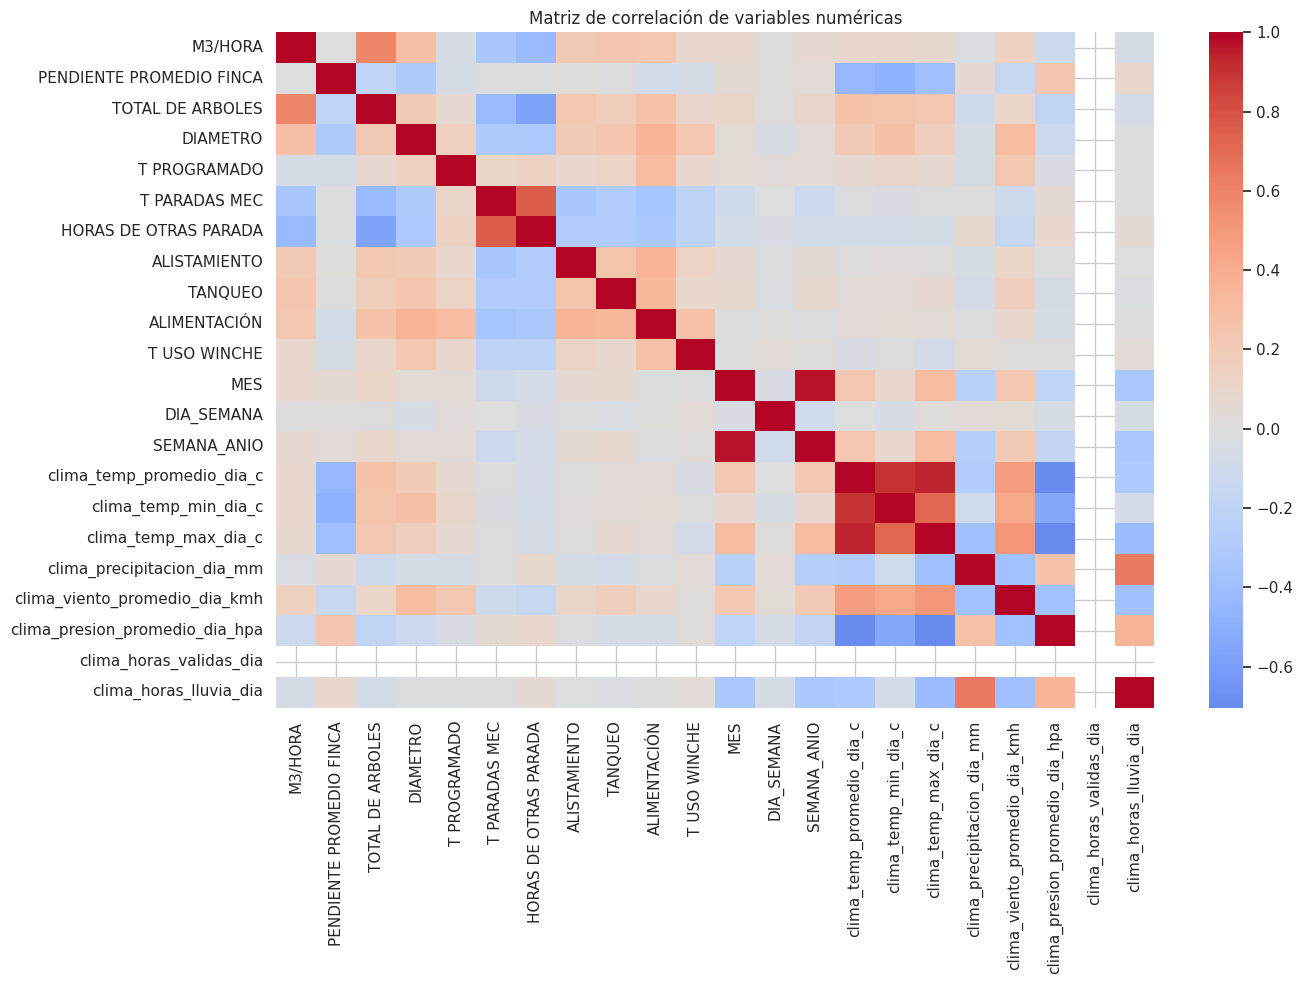

,M3/HORA,PENDIENTE PROMEDIO FINCA,TOTAL DE ARBOLES,DIAMETRO,T PROGRAMADO,T PARADAS MEC,HORAS DE OTRAS PARADA,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,MES,DIA_SEMANA,SEMANA_ANIO,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia
M3/HORA,1.0000,-0.0029,0.5888,0.2850,-0.0470,-0.3339,-0.4296,0.2188,0.2392,0.2296,0.0860,0.0814,0.0147,0.0642,0.0828,0.0853,0.0702,-0.0304,0.1433,-0.1214,NaN,-0.0612
PENDIENTE PROMEDIO FINCA,-0.0029,1.0000,-0.1995,-0.3018,-0.0515,-0.0222,-0.0139,0.0175,0.0027,-0.0840,-0.0558,0.0601,0.0216,0.0390,-0.4500,-0.4816,-0.3928,0.0684,-0.1546,0.2381,NaN,0.0820
TOTAL DE ARBOLES,0.5888,-0.1995,1.0000,0.2145,0.0668,-0.4284,-0.5733,0.2266,0.1798,0.2659,0.0955,0.1024,0.0127,0.0950,0.2651,0.2540,0.2226,-0.1058,0.1031,-0.1873,NaN,-0.0759
DIAMETRO,0.2850,-0.3018,0.2145,1.0000,0.1608,-0.2993,-0.3172,0.2007,0.2384,0.3482,0.2306,0.0441,-0.0444,0.0416,0.2015,0.2779,0.1644,-0.0585,0.3104,-0.1292,NaN,-0.0222
T PROGRAMADO,-0.0470,-0.0515,0.0668,0.1608,1.0000,0.1051,0.1403,0.0864,0.1314,0.3077,0.0797,0.0473,0.0283,0.0385,0.0670,0.0901,0.0675,-0.0581,0.2250,-0.0362,NaN,-0.0158
T PARADAS MEC,-0.3339,-0.0222,-0.4284,-0.2993,0.1051,1.0000,0.7591,-0.3310,-0.2926,-0.3515,-0.2123,-0.1072,-0.0043,-0.1163,-0.0164,-0.0314,-0.0147,0.0054,-0.1049,0.0521,NaN,0.0030
HORAS DE OTRAS PARADA,-0.4296,-0.0139,-0.5733,-0.3172,0.1403,0.7591,1.0000,-0.2874,-0.2910,-0.3194,-0.2100,-0.0736,-0.0333,-0.0757,-0.0676,-0.0768,-0.0620,0.0714,-0.1522,0.0841,NaN,0.0558
ALISTAMIENTO,0.2188,0.0175,0.2266,0.2007,0.0864,-0.3310,-0.2874,1.0000,0.2469,0.3564,0.1333,0.0633,-0.0135,0.0585,0.0125,0.0226,0.0199,-0.0509,0.1039,-0.0241,NaN,-0.0044
TANQUEO,0.2392,0.0027,0.1798,0.2384,0.1314,-0.2926,-0.2910,0.2469,1.0000,0.3368,0.0794,0.0710,-0.0270,0.0703,0.0397,0.0336,0.0660,-0.0679,0.1669,-0.0625,NaN,-0.0278
ALIMENTACIÓN,0.2296,-0.0840,0.2659,0.3482,0.3077,-0.3515,-0.3194,0.3564,0.3368,1.0000,0.2683,-0.0147,0.0109,-0.0194,0.0339,0.0458,0.0385,-0.0238,0.0773,-0.0475,NaN,0.0082


In [18]:
# ============================================================
# 17. MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ============================================================

numeric_corr_cols = [TARGET_COL] + numeric_features + date_features + climate_features_valid_eda
numeric_corr_cols = [c for c in numeric_corr_cols if c in df_clean.columns and df_clean[c].notna().sum() > 0]

corr_matrix = df_clean[numeric_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

display(corr_matrix)

## 18. Matriz de asociación entre variables categóricas

Se calcula la asociación entre variables categóricas mediante V de Cramér, con el fin de identificar relaciones estructurales entre equipo, zona, especie, contratista, finca, municipio, turno y suelo.

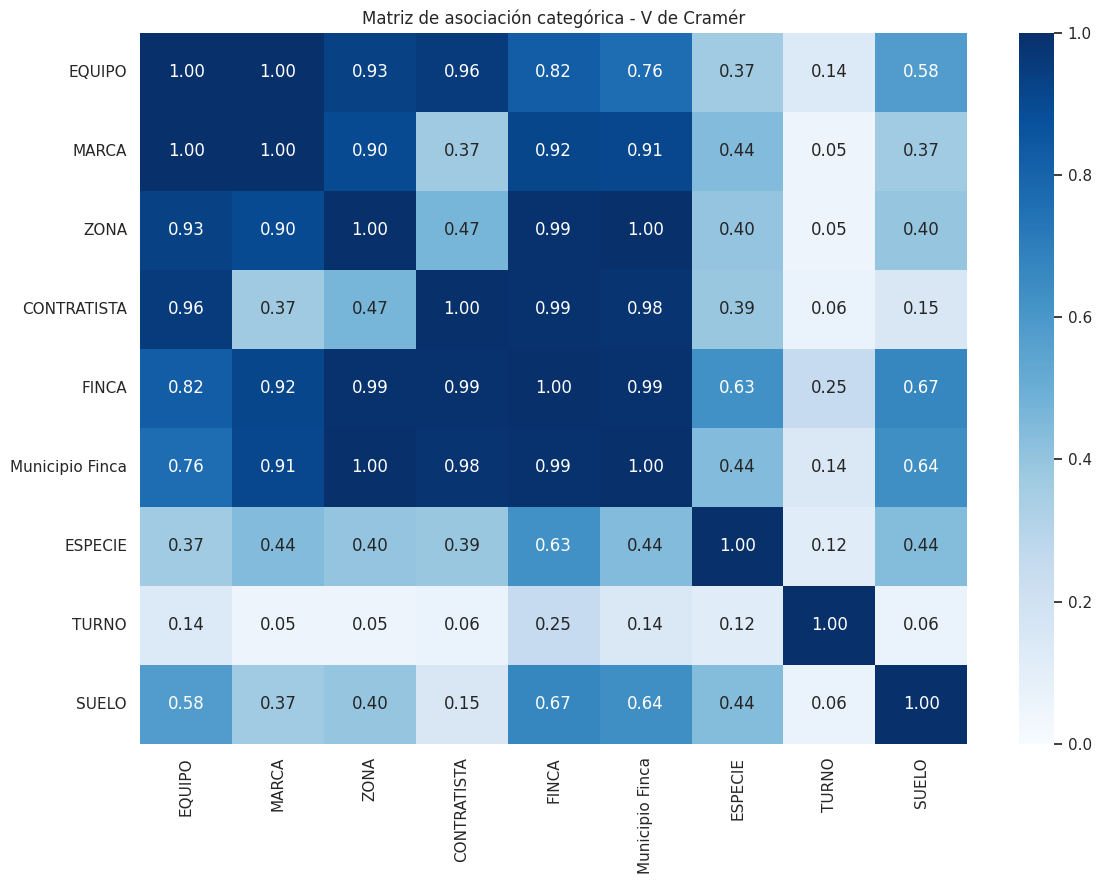

,EQUIPO,MARCA,ZONA,CONTRATISTA,FINCA,Municipio Finca,ESPECIE,TURNO,SUELO
EQUIPO,1.0000,0.9980,0.9335,0.9559,0.8246,0.7648,0.3690,0.1388,0.5816
MARCA,0.9980,1.0000,0.8995,0.3734,0.9170,0.9116,0.4434,0.0521,0.3679
ZONA,0.9335,0.8995,1.0000,0.4689,0.9894,0.9975,0.3997,0.0523,0.3966
CONTRATISTA,0.9559,0.3734,0.4689,1.0000,0.9894,0.9811,0.3883,0.0641,0.1547
FINCA,0.8246,0.9170,0.9894,0.9894,1.0000,0.9919,0.6263,0.2501,0.6695
Municipio Finca,0.7648,0.9116,0.9975,0.9811,0.9919,1.0000,0.4426,0.1448,0.6362
ESPECIE,0.3690,0.4434,0.3997,0.3883,0.6263,0.4426,1.0000,0.1157,0.4387
TURNO,0.1388,0.0521,0.0523,0.0641,0.2501,0.1448,0.1157,1.0000,0.0647
SUELO,0.5816,0.3679,0.3966,0.1547,0.6695,0.6362,0.4387,0.0647,1.0000


In [19]:
# ============================================================
# 18. MATRIZ DE ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS
# ============================================================

def cramers_v(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.empty:
        return np.nan

    confusion_matrix = pd.crosstab(valid["x"], valid["y"])
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min((kcorr - 1), (rcorr - 1))
    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)

cat_assoc_cols = [c for c in categorical_features if c in df_clean.columns]
cat_assoc_matrix = pd.DataFrame(index=cat_assoc_cols, columns=cat_assoc_cols, dtype=float)

for c1 in cat_assoc_cols:
    for c2 in cat_assoc_cols:
        if c1 == c2:
            cat_assoc_matrix.loc[c1, c2] = 1.0
        else:
            cat_assoc_matrix.loc[c1, c2] = cramers_v(df_clean[c1], df_clean[c2])

plt.figure(figsize=(12, 9))
sns.heatmap(cat_assoc_matrix.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Matriz de asociación categórica - V de Cramér")
plt.tight_layout()
plt.show()

display(cat_assoc_matrix)

## 19. Matriz categórica-numérica con `dython`

Se aplica `dython` para estimar asociaciones mixtas entre variables categóricas y numéricas. Este análisis complementa la correlación tradicional al incorporar relaciones no exclusivamente lineales.

Columnas categóricas usadas: 9
Columnas numéricas usadas: 21
Total columnas analizadas: 30


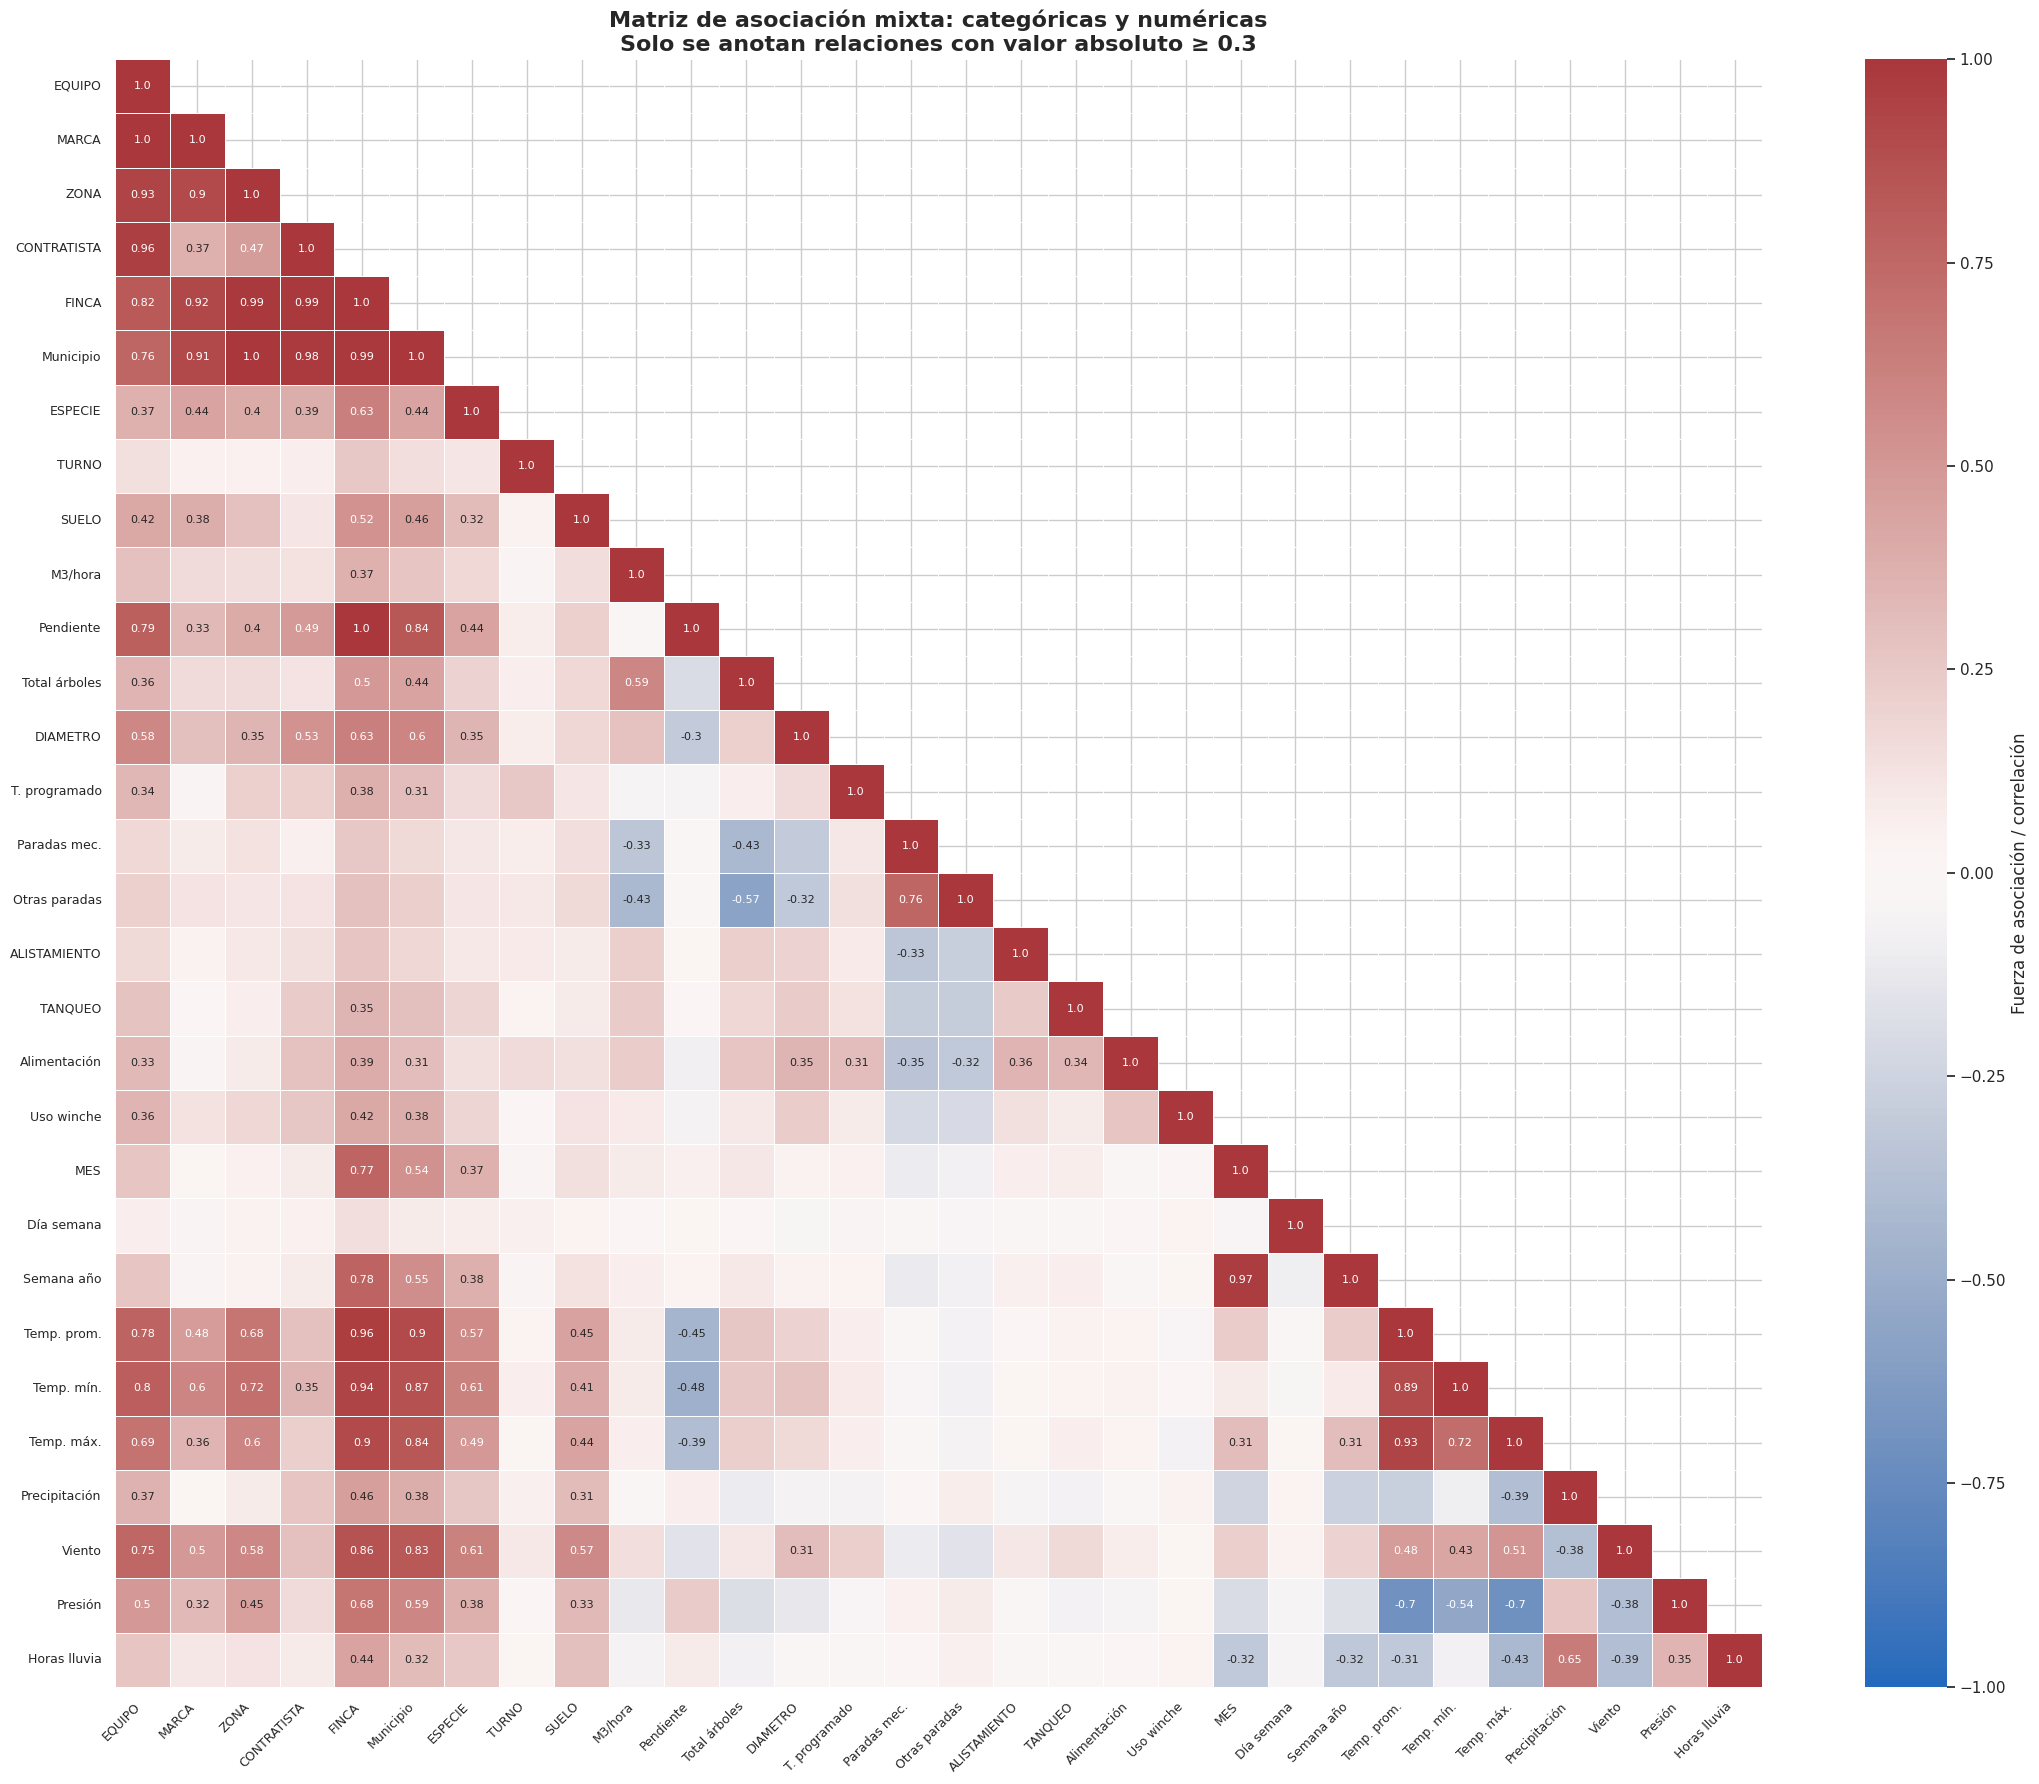

Top 30 relaciones más fuertes:


,Variable 1,Variable 2,Asociación,Fuerza absoluta,Tipo relación
115,FINCA,PENDIENTE PROMEDIO FINCA,1.0000,1.0000,Categórica - Numérica
0,EQUIPO,MARCA,0.9980,0.9980,Categórica - Categórica
59,ZONA,Municipio Finca,0.9975,0.9975,Categórica - Categórica
110,FINCA,Municipio Finca,0.9919,0.9919,Categórica - Categórica
58,ZONA,FINCA,0.9894,0.9894,Categórica - Categórica
84,CONTRATISTA,FINCA,0.9894,0.9894,Categórica - Categórica
85,CONTRATISTA,Municipio Finca,0.9811,0.9811,Categórica - Categórica
391,MES,SEMANA_ANIO,0.9710,0.9710,Numérica - Numérica
128,FINCA,clima_temp_promedio_dia_c,0.9646,0.9646,Categórica - Numérica
2,EQUIPO,CONTRATISTA,0.9559,0.9559,Categórica - Categórica


Variables más asociadas con M3/HORA:


,Asociación,Fuerza absoluta,Tipo variable
TOTAL DE ARBOLES,0.5888,0.5888,Numérica
HORAS DE OTRAS PARADA,-0.4296,0.4296,Numérica
FINCA,0.3678,0.3678,Categórica
T PARADAS MEC,-0.3339,0.3339,Numérica
EQUIPO,0.2921,0.2921,Categórica
DIAMETRO,0.2850,0.2850,Numérica
Municipio Finca,0.2721,0.2721,Categórica
TANQUEO,0.2392,0.2392,Numérica
ALIMENTACIÓN,0.2296,0.2296,Numérica
ALISTAMIENTO,0.2188,0.2188,Numérica


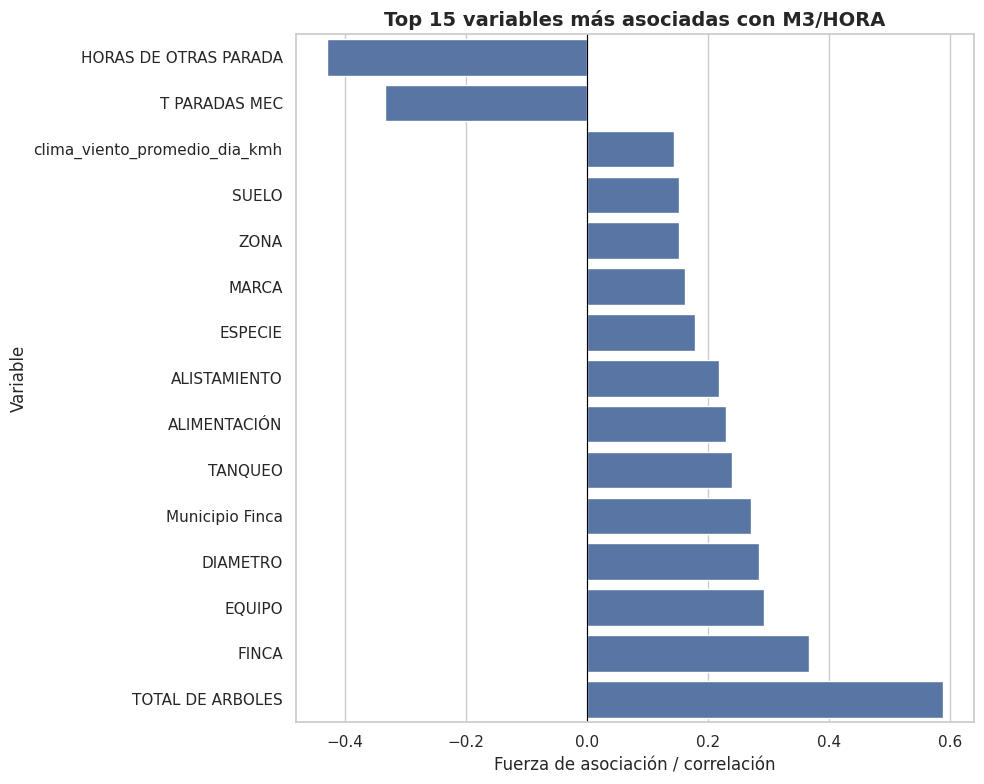

In [40]:
# ============================================================
# 19. MATRIZ CATEGÓRICA-NUMÉRICA MEJORADA CON DYTHON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ------------------------------------------------------------
# 1. Seleccionar columnas existentes
# ------------------------------------------------------------

cat_cols = [c for c in cat_assoc_cols if c in df_clean.columns]
num_cols = [c for c in numeric_corr_cols if c in df_clean.columns]

mixed_assoc_cols = list(dict.fromkeys(cat_cols + num_cols))
df_mixed = df_clean[mixed_assoc_cols].copy()

# ------------------------------------------------------------
# 2. Eliminar columnas vacías o constantes
# ------------------------------------------------------------

cols_utiles = [
    c for c in df_mixed.columns
    if df_mixed[c].notna().sum() > 0 and df_mixed[c].nunique(dropna=True) > 1
]

df_mixed = df_mixed[cols_utiles]
cat_cols = [c for c in cat_cols if c in cols_utiles]
num_cols = [c for c in num_cols if c in cols_utiles]

print(f"Columnas categóricas usadas: {len(cat_cols)}")
print(f"Columnas numéricas usadas: {len(num_cols)}")
print(f"Total columnas analizadas: {len(df_mixed.columns)}")

# ------------------------------------------------------------
# 3. Calcular matriz sin graficar directamente con dython
# ------------------------------------------------------------

if associations is not None:
    try:
        assoc_result = associations(
            df_mixed,
            nominal_columns=cat_cols,
            numerical_columns=num_cols,
            nom_nom_assoc="cramer",
            num_num_assoc="pearson",
            mark_columns=False,
            plot=False,
            compute_only=True
        )

        mixed_assoc_matrix = assoc_result["corr"].copy()

        # ------------------------------------------------------------
        # 4. Crear nombres más cortos para la gráfica
        # ------------------------------------------------------------

        def nombre_corto(col):
            reemplazos = {
                "Municipio Finca": "Municipio",
                "PENDIENTE PROMEDIO FINCA": "Pendiente",
                "TOTAL DE ARBOLES": "Total árboles",
                "T PROGRAMADO": "T. programado",
                "T PARADAS MEC": "Paradas mec.",
                "HORAS DE OTRAS PARADA": "Otras paradas",
                "ALIMENTACIÓN": "Alimentación",
                "T USO WINCHE": "Uso winche",
                "SEMANA_ANIO": "Semana año",
                "DIA_SEMANA": "Día semana",
                "M3/HORA": "M3/hora",
                "clima_temp_promedio_dia_c": "Temp. prom.",
                "clima_temp_min_dia_c": "Temp. mín.",
                "clima_temp_max_dia_c": "Temp. máx.",
                "clima_precipitacion_dia_mm": "Precipitación",
                "clima_viento_promedio_dia_kmh": "Viento",
                "clima_presion_promedio_dia_hpa": "Presión",
                "clima_horas_validas_dia": "Horas válidas",
                "clima_horas_lluvia_dia": "Horas lluvia",
            }
            return reemplazos.get(col, col)

        labels = [nombre_corto(c) for c in mixed_assoc_matrix.columns]

        plot_matrix = mixed_assoc_matrix.copy()
        plot_matrix.index = labels
        plot_matrix.columns = labels

        # ------------------------------------------------------------
        # 5. Heatmap limpio: solo media matriz y valores fuertes
        # ------------------------------------------------------------

        umbral = 0.30

        mask = np.triu(np.ones_like(plot_matrix, dtype=bool), k=1)

        annot = plot_matrix.where(plot_matrix.abs() >= umbral)
        annot = annot.round(2).astype(str).replace("nan", "")

        plt.figure(figsize=(22, 18))

        sns.heatmap(
            plot_matrix,
            mask=mask,
            cmap="vlag",
            center=0,
            vmin=-1,
            vmax=1,
            annot=annot,
            fmt="",
            linewidths=0.4,
            annot_kws={"size": 8},
            cbar_kws={"label": "Fuerza de asociación / correlación"}
        )

        plt.title(
            "Matriz de asociación mixta: categóricas y numéricas\n"
            f"Solo se anotan relaciones con valor absoluto ≥ {umbral}",
            fontsize=16,
            fontweight="bold"
        )

        plt.xticks(rotation=45, ha="right", fontsize=9)
        plt.yticks(rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()

        # ------------------------------------------------------------
        # 6. Tabla de las relaciones más fuertes
        # ------------------------------------------------------------

        matriz = mixed_assoc_matrix.copy()

        upper_mask = np.triu(np.ones(matriz.shape, dtype=bool), k=1)

        relaciones = (
            matriz.where(upper_mask)
            .stack()
            .reset_index()
        )

        relaciones.columns = ["Variable 1", "Variable 2", "Asociación"]
        relaciones["Fuerza absoluta"] = relaciones["Asociación"].abs()

        def tipo_variable(col):
            if col in cat_cols:
                return "Categórica"
            elif col in num_cols:
                return "Numérica"
            else:
                return "No clasificada"

        relaciones["Tipo relación"] = relaciones.apply(
            lambda row: f"{tipo_variable(row['Variable 1'])} - {tipo_variable(row['Variable 2'])}",
            axis=1
        )

        top_relaciones = (
            relaciones
            .sort_values("Fuerza absoluta", ascending=False)
            .head(30)
        )

        print("Top 30 relaciones más fuertes:")
        display(top_relaciones)

        # ------------------------------------------------------------
        # 7. Análisis enfocado en variable objetivo: M3/HORA
        # ------------------------------------------------------------

        variable_objetivo = "M3/HORA"

        if variable_objetivo in matriz.columns:

            target_assoc = matriz[variable_objetivo].drop(variable_objetivo).to_frame("Asociación")
            target_assoc["Fuerza absoluta"] = target_assoc["Asociación"].abs()
            target_assoc["Tipo variable"] = target_assoc.index.map(tipo_variable)

            target_assoc = target_assoc.sort_values("Fuerza absoluta", ascending=False)

            print(f"Variables más asociadas con {variable_objetivo}:")
            display(target_assoc.head(20))

            top_target = target_assoc.head(15).sort_values("Asociación")

            plt.figure(figsize=(10, 8))

            sns.barplot(
                data=top_target.reset_index(),
                x="Asociación",
                y="index"
            )

            plt.title(
                f"Top 15 variables más asociadas con {variable_objetivo}",
                fontsize=14,
                fontweight="bold"
            )

            plt.xlabel("Fuerza de asociación / correlación")
            plt.ylabel("Variable")
            plt.axvline(0, color="black", linewidth=0.8)
            plt.tight_layout()
            plt.show()

        else:
            print(f"La variable objetivo '{variable_objetivo}' no está en la matriz.")

    except Exception as exc:
        print("No fue posible calcular la matriz con dython.")
        print("Detalle del error:")
        print(exc)

else:
    print("La librería dython no está disponible en el entorno.")

## 20. Análisis de posible fuga de información

Se revisan variables que no deben incorporarse al modelo por estar directamente relacionadas con el cálculo de la productividad o por representar resultados posteriores de la operación.

In [21]:
# ============================================================
# 20. ANÁLISIS DE POSIBLE FUGA DE INFORMACIÓN
# ============================================================

leakage_review = []

for col in excluded_from_model:
    if col in df_clean.columns:
        col_num = pd.to_numeric(df_clean[col], errors="coerce")
        leakage_review.append({
            "variable": col,
            "existe_en_dataset": True,
            "valores_no_nulos": df_clean[col].notna().sum(),
            "valores_unicos": df_clean[col].nunique(dropna=True),
            "correlacion_con_target_si_numerica": col_num.corr(df_clean[TARGET_COL]) if col_num.notna().sum() > 2 else np.nan
        })
    else:
        leakage_review.append({
            "variable": col,
            "existe_en_dataset": False,
            "valores_no_nulos": 0,
            "valores_unicos": 0,
            "correlacion_con_target_si_numerica": np.nan
        })

leakage_df = pd.DataFrame(leakage_review)
display(leakage_df)

,variable,existe_en_dataset,valores_no_nulos,valores_unicos,correlacion_con_target_si_numerica
0,PRODUCTIVIDAD M3/H,True,1990,1149,1.0000
1,M3,True,1990,1139,0.8442
2,T EFECTIVO,False,0,0,NaN
3,ARB/HORA,False,0,0,NaN
4,FUSTES/HORA,True,1990,160,0.0553
5,VOL/ÁRBOL,False,0,0,NaN
6,E%,False,0,0,NaN
7,E% Global,False,0,0,NaN
8,DM%,True,1990,361,0.3259
9,Horas disponibles,True,1990,290,0.2868


## 21. Preparación del dataset analítico

Se construye la base final de modelado con registros válidos, productividad positiva, tratamiento de valores extremos de la variable objetivo y selección de predictores.

In [22]:
# ============================================================
# 21. PREPARACIÓN DEL DATASET ANALÍTICO
# ============================================================

climate_features_valid = [
    c for c in climate_features_expected
    if c in df_clean.columns and df_clean[c].notna().sum() > 0
]

categorical_model_features = [c for c in categorical_features if c in df_clean.columns]
numeric_model_features = [
    c for c in (numeric_features + date_features + climate_features_valid)
    if c in df_clean.columns
]

model_features = categorical_model_features + numeric_model_features

df_model = df_clean.copy()

df_model = df_model[df_model[TARGET_COL].notna()].copy()
df_model = df_model[df_model[TARGET_COL] > 0].copy()

q1 = df_model[TARGET_COL].quantile(0.25)
q3 = df_model[TARGET_COL].quantile(0.75)
iqr = q3 - q1
target_lower_bound = q1 - 1.5 * iqr
target_upper_bound = q3 + 1.5 * iqr

df_model["target_outlier_iqr"] = (
    (df_model[TARGET_COL] < target_lower_bound)
    | (df_model[TARGET_COL] > target_upper_bound)
)

df_model = df_model[~df_model["target_outlier_iqr"]].copy()

for col in numeric_model_features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

for col in categorical_model_features:
    df_model[col] = df_model[col].apply(clean_category_value)

X_model = df_model[model_features].copy()
y_model = df_model[TARGET_COL].copy()

print("Dimensión dataset analítico:")
print(f"X: {X_model.shape}")
print(f"y: {y_model.shape}")

print("Variables categóricas usadas:")
print(categorical_model_features)

print("Variables numéricas usadas:")
print(numeric_model_features)

display(df_model[[TARGET_COL] + model_features].head())

Dimensión dataset analítico:
X: (1575, 30)
y: (1575,)
Variables categóricas usadas:
['EQUIPO', 'MARCA', 'ZONA', 'CONTRATISTA', 'FINCA', 'Municipio Finca', 'ESPECIE', 'TURNO', 'SUELO']
Variables numéricas usadas:
['PENDIENTE PROMEDIO FINCA', 'TOTAL DE ARBOLES', 'DIAMETRO', 'T PROGRAMADO', 'T PARADAS MEC', 'HORAS DE OTRAS PARADA', 'ALISTAMIENTO', 'TANQUEO', 'ALIMENTACIÓN', 'T USO WINCHE', 'MES', 'DIA_SEMANA', 'SEMANA_ANIO', 'clima_temp_promedio_dia_c', 'clima_temp_min_dia_c', 'clima_temp_max_dia_c', 'clima_precipitacion_dia_mm', 'clima_viento_promedio_dia_kmh', 'clima_presion_promedio_dia_hpa', 'clima_horas_validas_dia', 'clima_horas_lluvia_dia']


,M3/HORA,EQUIPO,MARCA,ZONA,CONTRATISTA,FINCA,Municipio Finca,ESPECIE,TURNO,SUELO,PENDIENTE PROMEDIO FINCA,TOTAL DE ARBOLES,DIAMETRO,T PROGRAMADO,T PARADAS MEC,HORAS DE OTRAS PARADA,ALISTAMIENTO,TANQUEO,ALIMENTACIÓN,T USO WINCHE,MES,DIA_SEMANA,SEMANA_ANIO,clima_temp_promedio_dia_c,clima_temp_min_dia_c,clima_temp_max_dia_c,clima_precipitacion_dia_mm,clima_viento_promedio_dia_kmh,clima_presion_promedio_dia_hpa,clima_horas_validas_dia,clima_horas_lluvia_dia
0,8.9300,HVPO-4,PONSSE,CENTRO,EFAGRAM,35ALEJA,BOLIVAR,EUCALYPTUS GRANDIS,TURNO 1,HUMEDO,27.3109,214,18.0000,12.0000,3.0000,4.5000,0.5000,0.2500,0.7500,0.0000,1,1,3,13.9250,12.0000,18.7000,10.7000,3.4958,"1,014.2750",24,13
1,2.0000,HVPO-3,PONSSE,NORTE,EFAGRAM,12PERLA,GUATICA,EUCALYPTUS GRANDIS,TURNO 2,HUMEDO,17.4275,48,16.0000,8.0000,4.6000,5.5000,0.3000,0.3000,0.3000,0.0000,1,4,1,15.2333,13.6000,17.9000,11.4000,3.1167,"1,014.9125",24,18
2,10.4700,HVPO-3,PONSSE,NORTE,EFAGRAM,12PALMA,GUATICA,EUCALYPTUS GRANDIS,TURNO 1,HUMEDO,17.4321,306,19.0000,8.0000,0.2000,0.8300,0.2000,0.2000,0.2300,8.0000,1,1,4,15.0333,12.8000,20.7000,9.2000,4.0417,"1,014.1917",24,18
3,5.9600,HVPO-3,PONSSE,NORTE,EFAGRAM,12ARGEN,RIOSUCIO,PINUS TECUNUMANII,TURNO 2,HUMEDO,16.1293,113,30.0000,8.0000,1.0000,1.1700,0.1700,0.0000,0.0000,1.0000,2,6,5,13.5875,12.6000,16.4000,34.7000,2.8000,"1,018.1250",24,24
4,11.7000,HVPO-1,PONSSE,NORTE,GREEN FOREST,13SNGER,SEVILLA,PINUS TECUNUMANII,TURNO 2,HUMEDO,35.0868,112,0.0000,6.5000,0.8200,1.3500,0.3800,0.0000,0.1500,0.0000,3,6,10,15.5292,12.6000,19.3000,20.3000,3.2792,"1,012.8500",24,14


## 22. División entrenamiento-prueba

Se separa el dataset en conjuntos de entrenamiento y prueba para evaluar el desempeño del modelo sobre datos no utilizados durante el ajuste.

In [23]:
# ============================================================
# 22. DIVISIÓN ENTRENAMIENTO-PRUEBA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Prueba: {X_test.shape[0]:,} registros")

Entrenamiento: 1,260 registros
Prueba: 315 registros


## 23. Pipeline de preprocesamiento

Se construye un pipeline que integra imputación, tratamiento de valores extremos en predictores numéricos, estandarización y transformación de variables categóricas mediante One-Hot Encoding.

In [24]:
# ============================================================
# 23. PIPELINE DE PREPROCESAMIENTO
# ============================================================

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower_quantile=0.01, upper_quantile=0.99)),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_model_features),
        ("cat", categorical_pipeline, categorical_model_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

print("Pipeline de preprocesamiento definido correctamente.")

Pipeline de preprocesamiento definido correctamente.


## 24. Modelo base de regresión lineal múltiple

Se entrena una regresión lineal múltiple como modelo principal, debido a su utilidad para estimar una variable continua y facilitar la interpretación de coeficientes.

In [25]:
# ============================================================
# 24. MODELO BASE DE REGRESIÓN LINEAL MÚLTIPLE
# ============================================================

linear_model = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Modelo de regresión lineal entrenado correctamente.")

Modelo de regresión lineal entrenado correctamente.


## 25. Evaluación del modelo base

Se calculan las métricas MAE, RMSE y R² para interpretar el error promedio, la penalización de errores grandes y la capacidad explicativa del modelo.

,modelo,MAE,RMSE,R2
0,Regresión lineal base,3.5023,4.7894,0.4709


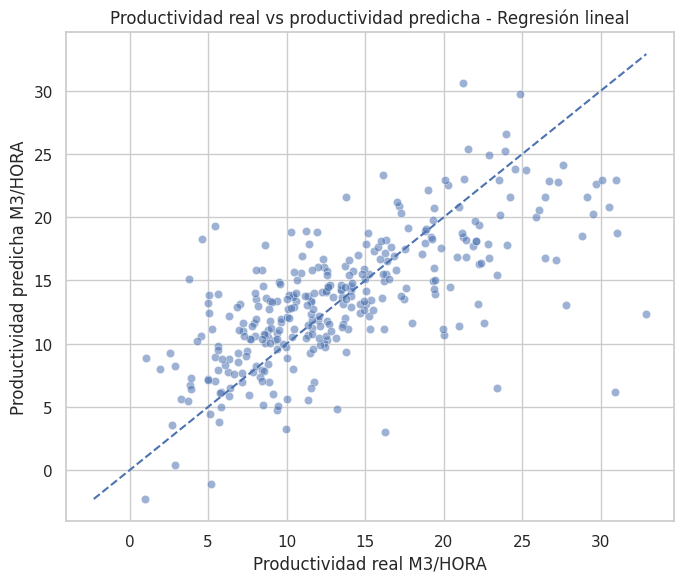

In [26]:
# ============================================================
# 25. EVALUACIÓN DEL MODELO BASE
# ============================================================

def rmse_score(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def evaluate_model(model, X_eval, y_eval, model_name):
    pred = model.predict(X_eval)
    return {
        "modelo": model_name,
        "MAE": mean_absolute_error(y_eval, pred),
        "RMSE": rmse_score(y_eval, pred),
        "R2": r2_score(y_eval, pred),
    }

linear_metrics = evaluate_model(linear_model, X_test, y_test, "Regresión lineal base")
metrics_table = pd.DataFrame([linear_metrics])
display(metrics_table)

y_pred_linear = linear_model.predict(X_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.55)
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Productividad real vs productividad predicha - Regresión lineal")
plt.xlabel("Productividad real M3/HORA")
plt.ylabel("Productividad predicha M3/HORA")
plt.tight_layout()
plt.show()

## 26. Validación cruzada K-Fold

Se aplica validación cruzada con diez particiones para evaluar la estabilidad del modelo y obtener una estimación más robusta del desempeño.

In [27]:
# ============================================================
# 26. VALIDACIÓN CRUZADA K-FOLD
# ============================================================

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results_linear = cross_validate(
    linear_model,
    X_model,
    y_model,
    cv=kfold,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
    n_jobs=-1,
    return_train_score=False
)

cv_linear_summary = pd.DataFrame({
    "modelo": ["Regresión lineal CV"],
    "MAE_CV_promedio": [-cv_results_linear["test_MAE"].mean()],
    "MAE_CV_desviacion": [cv_results_linear["test_MAE"].std()],
    "RMSE_CV_promedio": [-cv_results_linear["test_RMSE"].mean()],
    "RMSE_CV_desviacion": [cv_results_linear["test_RMSE"].std()],
    "R2_CV_promedio": [cv_results_linear["test_R2"].mean()],
    "R2_CV_desviacion": [cv_results_linear["test_R2"].std()],
})

display(cv_linear_summary)

,modelo,MAE_CV_promedio,MAE_CV_desviacion,RMSE_CV_promedio,RMSE_CV_desviacion,R2_CV_promedio,R2_CV_desviacion
0,Regresión lineal CV,3.3452,0.2522,4.5053,0.3928,0.5058,0.0781


## 27. Validación de supuestos de regresión lineal

Se revisan linealidad, independencia de errores, homocedasticidad, normalidad de residuos y multicolinealidad mediante gráficos, pruebas estadísticas y VIF.

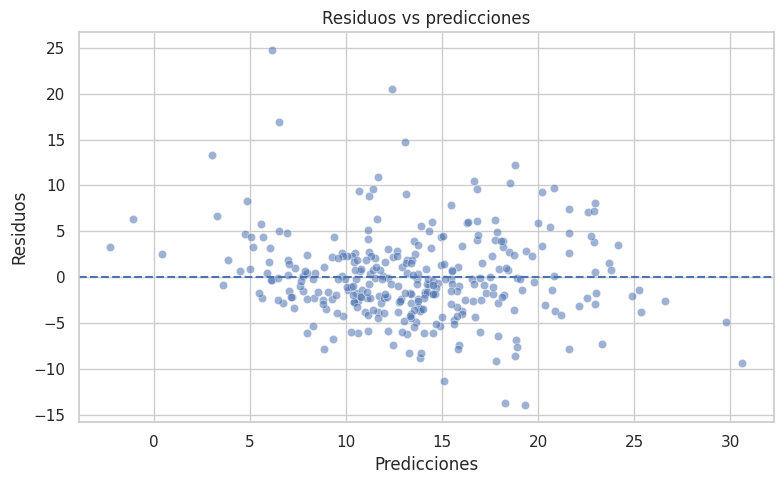

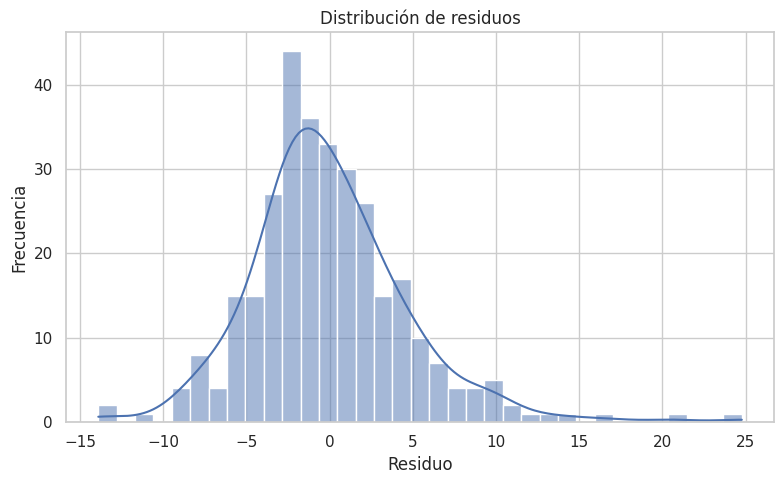

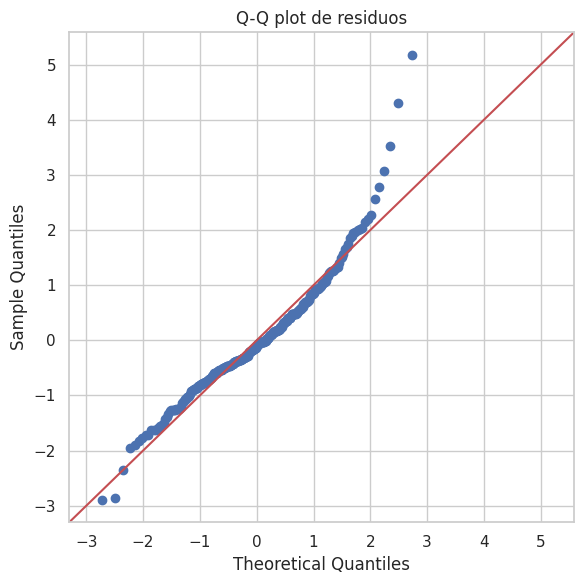

,prueba,valor
0,Durbin-Watson,2.0354
1,Jarque-Bera estadístico,201.6817
2,Jarque-Bera p-value,0.0000
3,Shapiro-Wilk estadístico,0.9478
4,Shapiro-Wilk p-value,0.0000
5,Breusch-Pagan LM,0.0224
6,Breusch-Pagan p-value,0.8810


,variable,VIF
13,clima_temp_promedio_dia_c,"2,741.0858"
15,clima_temp_max_dia_c,990.0764
14,clima_temp_min_dia_c,546.7172
18,clima_presion_promedio_dia_hpa,231.0207
10,MES,107.2325
12,SEMANA_ANIO,90.9068
3,T PROGRAMADO,76.0811
0,PENDIENTE PROMEDIO FINCA,25.3733
17,clima_viento_promedio_dia_kmh,16.7469
19,clima_horas_lluvia_dia,13.5482


In [28]:
# ============================================================
# 27. VALIDACIÓN DE SUPUESTOS DE REGRESIÓN LINEAL
# ============================================================

y_pred = linear_model.predict(X_test)
residuals = y_test - y_pred

assumption_summary = {}

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.55)
plt.axhline(0, linestyle="--")
plt.title("Residuos vs predicciones")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=35)
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line="45", fit=True, ax=plt.gca())
plt.title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

dw_stat = durbin_watson(residuals)
assumption_summary["Durbin-Watson"] = dw_stat

jb_stat, jb_pvalue = stats.jarque_bera(residuals)
assumption_summary["Jarque-Bera estadístico"] = jb_stat
assumption_summary["Jarque-Bera p-value"] = jb_pvalue

if len(residuals) <= 5000:
    shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)
    assumption_summary["Shapiro-Wilk estadístico"] = shapiro_stat
    assumption_summary["Shapiro-Wilk p-value"] = shapiro_pvalue

bp_exog = sm.add_constant(pd.Series(y_pred, name="predicciones"))
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuals, bp_exog)
assumption_summary["Breusch-Pagan LM"] = bp_lm
assumption_summary["Breusch-Pagan p-value"] = bp_lm_pvalue

assumption_df = pd.DataFrame(
    [{"prueba": k, "valor": v} for k, v in assumption_summary.items()]
)
display(assumption_df)

vif_num_df = df_model[numeric_model_features].copy()
vif_num_df = vif_num_df.apply(pd.to_numeric, errors="coerce")
vif_num_df = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(vif_num_df),
    columns=numeric_model_features
)

vif_num_df = vif_num_df.loc[:, vif_num_df.std() > 0]

vif_records = []
for i, col in enumerate(vif_num_df.columns):
    try:
        vif_records.append({
            "variable": col,
            "VIF": variance_inflation_factor(vif_num_df.values, i)
        })
    except Exception:
        vif_records.append({
            "variable": col,
            "VIF": np.nan
        })

vif_table = pd.DataFrame(vif_records).sort_values("VIF", ascending=False)
display(vif_table)

## 28. Modelo Ridge Regression

Se entrena una regresión Ridge como alternativa regularizada para mejorar la estabilidad de coeficientes ante posibles relaciones fuertes entre predictores.

In [29]:
# ============================================================
# 28. MODELO RIDGE REGRESSION
# ============================================================

ridge_model = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_metrics = evaluate_model(ridge_model, X_test, y_test, "Ridge alpha=1")
metrics_table = pd.concat([metrics_table, pd.DataFrame([ridge_metrics])], ignore_index=True)

display(metrics_table)

,modelo,MAE,RMSE,R2
0,Regresión lineal base,3.5023,4.7894,0.4709
1,Ridge alpha=1,3.4520,4.7428,0.4811


## 29. Optimización con Grid Search

Se aplica búsqueda en grilla sobre el hiperparámetro `alpha` de Ridge para identificar una configuración con menor error promedio.

In [30]:
# ============================================================
# 29. OPTIMIZACIÓN CON GRID SEARCH
# ============================================================

ridge_grid_pipeline = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": np.logspace(-3, 4, 25)
}

grid_search = GridSearchCV(
    estimator=ridge_grid_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kfold,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

ridge_grid_model = grid_search.best_estimator_
ridge_grid_metrics = evaluate_model(ridge_grid_model, X_test, y_test, "Ridge Grid Search")

metrics_table = pd.concat([metrics_table, pd.DataFrame([ridge_grid_metrics])], ignore_index=True)

print(f"Mejor alpha Grid Search: {grid_search.best_params_['model__alpha']:.6f}")
display(metrics_table)

Mejor alpha Grid Search: 1.615598


,modelo,MAE,RMSE,R2
0,Regresión lineal base,3.5023,4.7894,0.4709
1,Ridge alpha=1,3.4520,4.7428,0.4811
2,Ridge Grid Search,3.4428,4.7315,0.4836


## 30. Optimización bayesiana con Optuna

Se utiliza optimización bayesiana para buscar el hiperparámetro `alpha` de Ridge de manera eficiente, maximizando el desempeño mediante validación cruzada.

In [31]:
# ============================================================
# 30. OPTIMIZACIÓN BAYESIANA CON OPTUNA
# ============================================================

if optuna is None:
    print("Optuna no está disponible. Ejecute la instalación de librerías inicial o revise el entorno.")
    ridge_optuna_model = None
else:
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-4, 1e4, log=True)

        model = Pipeline(steps=[
            ("preprocess", clone(preprocessor)),
            ("model", Ridge(alpha=alpha))
        ])

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=kfold,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )

        return -scores.mean()

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=40, show_progress_bar=False)

    best_alpha_optuna = study.best_params["alpha"]

    ridge_optuna_model = Pipeline(steps=[
        ("preprocess", clone(preprocessor)),
        ("model", Ridge(alpha=best_alpha_optuna))
    ])

    ridge_optuna_model.fit(X_train, y_train)

    ridge_optuna_metrics = evaluate_model(ridge_optuna_model, X_test, y_test, "Ridge Optuna")

    metrics_table = pd.concat([metrics_table, pd.DataFrame([ridge_optuna_metrics])], ignore_index=True)

    print(f"Mejor alpha Optuna: {best_alpha_optuna:.6f}")
    display(metrics_table)

Mejor alpha Optuna: 2.224827


,modelo,MAE,RMSE,R2
0,Regresión lineal base,3.5023,4.7894,0.4709
1,Ridge alpha=1,3.4520,4.7428,0.4811
2,Ridge Grid Search,3.4428,4.7315,0.4836
3,Ridge Optuna,3.4360,4.7244,0.4851


## 31. Comparación final de modelos

Se consolida el desempeño de los modelos evaluados mediante MAE, RMSE y R², y se selecciona el modelo con menor MAE en el conjunto de prueba.

In [32]:
# ============================================================
# 31. COMPARACIÓN FINAL DE MODELOS
# ============================================================

candidate_models = {
    "Regresión lineal base": linear_model,
    "Ridge alpha=1": ridge_model,
    "Ridge Grid Search": ridge_grid_model,
}

if "ridge_optuna_model" in globals() and ridge_optuna_model is not None:
    candidate_models["Ridge Optuna"] = ridge_optuna_model

metrics_table = metrics_table.drop_duplicates(subset=["modelo"], keep="last").sort_values("MAE")
display(metrics_table)

best_model_name = metrics_table.iloc[0]["modelo"]
best_model = candidate_models[best_model_name]

print(f"Modelo seleccionado por menor MAE en prueba: {best_model_name}")

,modelo,MAE,RMSE,R2
3,Ridge Optuna,3.4360,4.7244,0.4851
2,Ridge Grid Search,3.4428,4.7315,0.4836
1,Ridge alpha=1,3.4520,4.7428,0.4811
0,Regresión lineal base,3.5023,4.7894,0.4709


Modelo seleccionado por menor MAE en prueba: Ridge Optuna


## 32. Importancia de variables por permutación

Se calcula la importancia de variables mediante permutación, evaluando el incremento del error cuando la información de cada predictor es alterada.

,variable,importancia_media_incremento_MAE,importancia_desviacion
10,TOTAL DE ARBOLES,2.6809,0.2506
0,EQUIPO,0.5960,0.0661
4,FINCA,0.3907,0.0643
6,ESPECIE,0.3674,0.0603
21,SEMANA_ANIO,0.3382,0.0636
14,HORAS DE OTRAS PARADA,0.3117,0.0657
5,Municipio Finca,0.2604,0.0459
23,clima_temp_min_dia_c,0.2387,0.0388
19,MES,0.2135,0.0282
1,MARCA,0.1609,0.0358


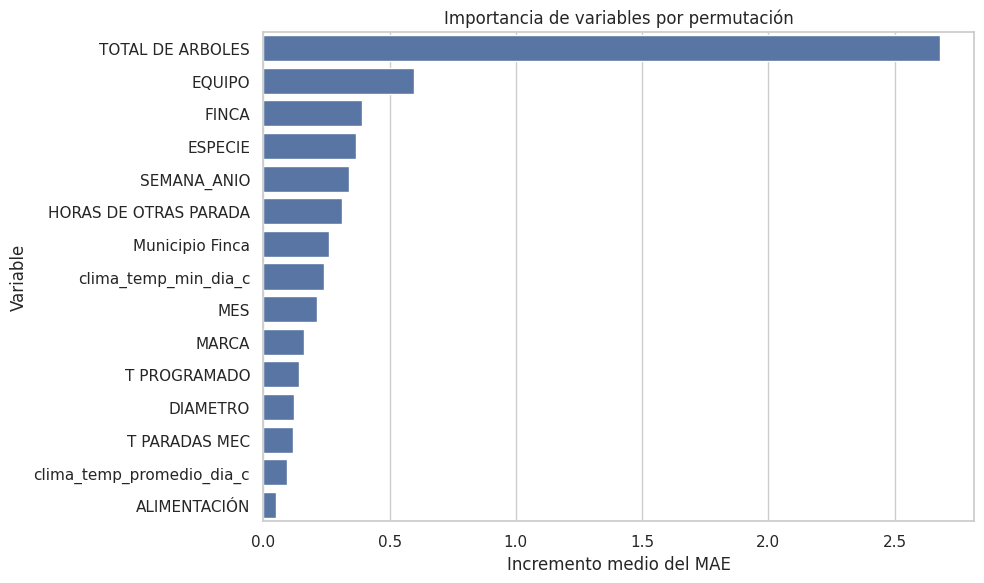

In [33]:
# ============================================================
# 32. IMPORTANCIA DE VARIABLES POR PERMUTACIÓN
# ============================================================

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "variable": X_test.columns,
    "importancia_media_incremento_MAE": perm_importance.importances_mean,
    "importancia_desviacion": perm_importance.importances_std
}).sort_values("importancia_media_incremento_MAE", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="importancia_media_incremento_MAE",
    y="variable"
)
plt.title("Importancia de variables por permutación")
plt.xlabel("Incremento medio del MAE")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 33. Interpretación de coeficientes

Se extraen los coeficientes del modelo seleccionado para identificar relaciones positivas y negativas entre predictores transformados y productividad.

In [34]:
# ============================================================
# 33. INTERPRETACIÓN DE COEFICIENTES
# ============================================================

def get_transformed_feature_names(fitted_pipeline):
    pre = fitted_pipeline.named_steps["preprocess"]
    try:
        return pre.get_feature_names_out()
    except Exception:
        names = []
        if numeric_model_features:
            names.extend([f"num__{c}" for c in numeric_model_features])
        try:
            ohe = pre.named_transformers_["cat"].named_steps["onehot"]
            cat_names = ohe.get_feature_names_out(categorical_model_features)
            names.extend([f"cat__{c}" for c in cat_names])
        except Exception:
            pass
        return np.array(names)

if hasattr(best_model.named_steps["model"], "coef_"):
    feature_names_transformed = get_transformed_feature_names(best_model)
    coefficients = best_model.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "variable_transformada": feature_names_transformed[:len(coefficients)],
        "coeficiente": coefficients[:len(feature_names_transformed)]
    })

    coef_df["impacto_absoluto"] = coef_df["coeficiente"].abs()
    coef_df = coef_df.sort_values("impacto_absoluto", ascending=False)

    display(coef_df.head(30))

    display(Markdown("### Variables con mayor relación positiva"))
    display(coef_df.sort_values("coeficiente", ascending=False).head(15))

    display(Markdown("### Variables con mayor relación negativa"))
    display(coef_df.sort_values("coeficiente", ascending=True).head(15))
else:
    coef_df = pd.DataFrame()
    print("El modelo seleccionado no expone coeficientes interpretables.")

,variable_transformada,coeficiente,impacto_absoluto
102,cat__ESPECIE_PINUS PATULA,4.7147,4.7147
1,num__TOTAL DE ARBOLES,4.2882,4.2882
24,cat__EQUIPO_HVJD-4,3.8899,3.8899
82,cat__FINCA_38MUNEC,-3.5307,3.5307
60,cat__FINCA_31PALES,-3.2230,3.2230
57,cat__FINCA_31ALASK,2.9456,2.9456
43,cat__FINCA_12PINTA,2.8884,2.8884
21,cat__EQUIPO_HVJD-1,-2.6945,2.6945
44,cat__FINCA_13ALSAC,-2.6500,2.6500
50,cat__FINCA_13MIMBR,2.5139,2.5139


### Variables con mayor relación positiva

,variable_transformada,coeficiente,impacto_absoluto
102,cat__ESPECIE_PINUS PATULA,4.7147,4.7147
1,num__TOTAL DE ARBOLES,4.2882,4.2882
24,cat__EQUIPO_HVJD-4,3.8899,3.8899
57,cat__FINCA_31ALASK,2.9456,2.9456
43,cat__FINCA_12PINTA,2.8884,2.8884
50,cat__FINCA_13MIMBR,2.5139,2.5139
93,cat__Municipio Finca_VIJES,2.1485,2.1485
76,cat__FINCA_35CAROL,1.8330,1.8330
92,cat__Municipio Finca_SEVILLA,1.7367,1.7367
47,cat__FINCA_13CRIST,1.6861,1.6861


### Variables con mayor relación negativa

,variable_transformada,coeficiente,impacto_absoluto
82,cat__FINCA_38MUNEC,-3.5307,3.5307
60,cat__FINCA_31PALES,-3.2230,3.2230
21,cat__EQUIPO_HVJD-1,-2.6945,2.6945
44,cat__FINCA_13ALSAC,-2.6500,2.6500
59,cat__FINCA_31GRACI,-2.4718,2.4718
100,cat__ESPECIE_PINUS KESIYA,-2.1990,2.1990
42,cat__FINCA_12PERLA,-2.1775,2.1775
73,cat__FINCA_34SUIZA,-2.1406,2.1406
46,cat__FINCA_13CANAD,-2.1355,2.1355
91,cat__Municipio Finca_SANTA_ROSA_CABAL,-1.6869,1.6869


## 34. Ranking de variables influyentes

Se organiza la evidencia de importancia e interpretación para sintetizar los principales factores operativos, forestales, geográficos, climáticos y organizacionales asociados a la productividad.

In [35]:
# ============================================================
# 34. RANKING DE VARIABLES INFLUYENTES
# ============================================================

ranking_variables = importance_df.copy()
ranking_variables["ranking"] = range(1, len(ranking_variables) + 1)

display(ranking_variables.head(20))

top_variables_text = ", ".join(ranking_variables.head(8)["variable"].tolist())
print(f"Principales variables según importancia por permutación: {top_variables_text}")

,variable,importancia_media_incremento_MAE,importancia_desviacion,ranking
10,TOTAL DE ARBOLES,2.6809,0.2506,1
0,EQUIPO,0.5960,0.0661,2
4,FINCA,0.3907,0.0643,3
6,ESPECIE,0.3674,0.0603,4
21,SEMANA_ANIO,0.3382,0.0636,5
14,HORAS DE OTRAS PARADA,0.3117,0.0657,6
5,Municipio Finca,0.2604,0.0459,7
23,clima_temp_min_dia_c,0.2387,0.0388,8
19,MES,0.2135,0.0282,9
1,MARCA,0.1609,0.0358,10


Principales variables según importancia por permutación: TOTAL DE ARBOLES, EQUIPO, FINCA, ESPECIE, SEMANA_ANIO, HORAS DE OTRAS PARADA, Municipio Finca, clima_temp_min_dia_c


## 35. Exportación de resultados, archivos para Power BI y artifacts para Streamlit

Se exportan predicciones, métricas, importancia de variables, coeficientes y artifacts del modelo. Las salidas permiten visualizar productividad real vs predicha en Power BI y desplegar el pipeline en una aplicación Streamlit.

In [39]:
# ============================================================
# 35. EXPORTACIÓN DE RESULTADOS, POWER BI Y ARTIFACTS STREAMLIT
# ============================================================

all_predictions = best_model.predict(X_model)

predictions_powerbi = df_model.copy()
predictions_powerbi["PRODUCTIVIDAD_REAL_M3_HORA"] = y_model.values
predictions_powerbi["PRODUCTIVIDAD_PREDICHA_M3_HORA"] = all_predictions
predictions_powerbi["ERROR"] = predictions_powerbi["PRODUCTIVIDAD_REAL_M3_HORA"] - predictions_powerbi["PRODUCTIVIDAD_PREDICHA_M3_HORA"]
predictions_powerbi["ERROR_ABSOLUTO"] = predictions_powerbi["ERROR"].abs()
predictions_powerbi["ERROR_PORCENTUAL_ABS"] = np.where(
    predictions_powerbi["PRODUCTIVIDAD_REAL_M3_HORA"] != 0,
    predictions_powerbi["ERROR_ABSOLUTO"] / predictions_powerbi["PRODUCTIVIDAD_REAL_M3_HORA"] * 100,
    np.nan
)

predictions_powerbi["CONJUNTO"] = "NO_ASIGNADO"
predictions_powerbi.loc[X_train.index, "CONJUNTO"] = "ENTRENAMIENTO"
predictions_powerbi.loc[X_test.index, "CONJUNTO"] = "PRUEBA"
predictions_powerbi["MODELO_SELECCIONADO"] = best_model_name

powerbi_cols = [
    "FECHA",
    "MES",
    "SEMANA_ANIO",
    "DIA_SEMANA",
    "EQUIPO",
    "MARCA",
    "ZONA",
    "CONTRATISTA",
    "FINCA",
    "Municipio Finca",
    "ESPECIE",
    "TURNO",
    "SUELO",
    "PENDIENTE PROMEDIO FINCA",
    "TOTAL DE ARBOLES",
    "DIAMETRO",
    "T PROGRAMADO",
    "T PARADAS MEC",
    "T Paradas Mec Mantenimiento",
    "HORAS DE OTRAS PARADA",
    "ALISTAMIENTO",
    "TANQUEO",
    "ALIMENTACIÓN",
    "T USO WINCHE",
] + climate_features_valid + [
    "PRODUCTIVIDAD_REAL_M3_HORA",
    "PRODUCTIVIDAD_PREDICHA_M3_HORA",
    "ERROR",
    "ERROR_ABSOLUTO",
    "ERROR_PORCENTUAL_ABS",
    "CONJUNTO",
    "MODELO_SELECCIONADO",
]

powerbi_cols = [c for c in powerbi_cols if c in predictions_powerbi.columns]

powerbi_predictions_path = OUTPUT_DIR / "powerbi_productividad_real_vs_predicha.csv"
powerbi_metrics_path = OUTPUT_DIR / "powerbi_metricas_modelo.csv"

predictions_powerbi[powerbi_cols].to_csv(powerbi_predictions_path, index=False, encoding="utf-8-sig")
metrics_table.to_csv(powerbi_metrics_path, index=False, encoding="utf-8-sig")

importance_path = OUTPUT_DIR / "importancia_variables_permutacion.csv"
coefficients_path = OUTPUT_DIR / "coeficientes_modelo.csv"
ranking_path = OUTPUT_DIR / "ranking_variables_influyentes.csv"

importance_df.to_csv(importance_path, index=False, encoding="utf-8-sig")
ranking_variables.to_csv(ranking_path, index=False, encoding="utf-8-sig")

if not coef_df.empty:
    coef_df.to_csv(coefficients_path, index=False, encoding="utf-8-sig")

final_model_for_deploy = clone(best_model)
final_model_for_deploy.fit(X_model, y_model)

model_path = ARTIFACTS_DIR / "modelo_productividad_harvester.pkl"
joblib.dump(final_model_for_deploy, model_path)

metadata = {
    "nombre_modelo": "Modelo de productividad Harvester",
    "modelo_seleccionado": best_model_name,
    "variable_objetivo": TARGET_COL,
    "variables_categoricas": categorical_model_features,
    "variables_numericas": numeric_model_features,
    "variables_climaticas_validas": climate_features_valid,
    "variables_modelo": model_features,
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "registros_modelo": int(len(df_model)),
    "metricas_prueba": metrics_table.to_dict(orient="records"),
    "limite_iqr_target_inferior": float(target_lower_bound),
    "limite_iqr_target_superior": float(target_upper_bound),
    "archivo_powerbi_predicciones": str(powerbi_predictions_path),
    "archivo_powerbi_metricas": str(powerbi_metrics_path),
}

metadata_path = ARTIFACTS_DIR / "metadata_modelo.json"
columns_path = ARTIFACTS_DIR / "columnas_modelo.json"
categories_path = ARTIFACTS_DIR / "categorias_modelo.json"
reference_dataset_path = ARTIFACTS_DIR / "dataset_referencia_streamlit.csv"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

with open(columns_path, "w", encoding="utf-8") as f:
    json.dump(model_features, f, ensure_ascii=False, indent=4)

categorias_modelo = {
    col: sorted(df_model[col].dropna().astype(str).unique().tolist())
    for col in categorical_model_features
}

with open(categories_path, "w", encoding="utf-8") as f:
    json.dump(categorias_modelo, f, ensure_ascii=False, indent=4)

reference_cols = model_features + [TARGET_COL]
df_model[reference_cols].head(300).to_csv(reference_dataset_path, index=False, encoding="utf-8-sig")

exported_files = pd.DataFrame({
    "tipo": [
        "Power BI",
        "Power BI",
        "Resultado complementario",
        "Resultado complementario",
        "Resultado complementario",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
        "Streamlit artifact",
    ],
    "archivo": [
        str(powerbi_predictions_path),
        str(powerbi_metrics_path),
        str(importance_path),
        str(ranking_path),
        str(coefficients_path) if not coef_df.empty else "No generado",
        str(model_path),
        str(metadata_path),
        str(columns_path),
        str(categories_path),
        str(reference_dataset_path),
        str(TRANSFORMERS_MODULE_PATH),
    ]
})

# ============================================================
# 35.1 EMPAQUETADO Y DESCARGA MASIVA DE ARCHIVOS EXPORTADOS
# ============================================================

from zipfile import ZipFile, ZIP_DEFLATED
from pathlib import Path

# Archivo comprimido final
zip_path = OUTPUT_DIR / "paquete_resultados_harvester.zip"

# Consolidación de archivos existentes para descarga
files_to_package = exported_files.copy()
files_to_package = files_to_package[
    files_to_package["archivo"].notna()
    & (files_to_package["archivo"] != "No generado")
].copy()

files_to_package["archivo_path"] = files_to_package["archivo"].apply(lambda x: Path(x))
files_to_package["existe"] = files_to_package["archivo_path"].apply(lambda x: x.exists())

# Empaquetar únicamente archivos existentes
with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as zipf:
    for _, row in files_to_package[files_to_package["existe"]].iterrows():
        file_path = row["archivo_path"]

        # Organización interna del ZIP por tipo de archivo
        tipo_limpio = (
            str(row["tipo"])
            .lower()
            .replace(" ", "_")
            .replace("á", "a")
            .replace("é", "e")
            .replace("í", "i")
            .replace("ó", "o")
            .replace("ú", "u")
        )

        arcname = f"{tipo_limpio}/{file_path.name}"
        zipf.write(file_path, arcname=arcname)

# Registrar el paquete ZIP dentro del resumen de exportación
zip_row = pd.DataFrame({
    "tipo": ["Paquete descarga masiva"],
    "archivo": [str(zip_path)]
})

exported_files_final = pd.concat(
    [exported_files, zip_row],
    ignore_index=True
)

display(exported_files_final)

print("Exportación finalizada correctamente.")
print(f"Archivo ZIP generado: {zip_path}")

# Descarga automática en Google Colab
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("No se detectó entorno Google Colab.")
    print("El archivo ZIP quedó disponible en la ruta indicada.")

,tipo,archivo
0,Power BI,outputs/powerbi_productividad_real_vs_predicha...
1,Power BI,outputs/powerbi_metricas_modelo.csv
2,Resultado complementario,outputs/importancia_variables_permutacion.csv
3,Resultado complementario,outputs/ranking_variables_influyentes.csv
4,Resultado complementario,outputs/coeficientes_modelo.csv
5,Streamlit artifact,artifacts/modelo_productividad_harvester.pkl
6,Streamlit artifact,artifacts/metadata_modelo.json
7,Streamlit artifact,artifacts/columnas_modelo.json
8,Streamlit artifact,artifacts/categorias_modelo.json
9,Streamlit artifact,artifacts/dataset_referencia_streamlit.csv


Exportación finalizada correctamente.
Archivo ZIP generado: outputs/paquete_resultados_harvester.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 36. Conclusiones técnicas del notebook

Se sintetizan los hallazgos principales del análisis: desempeño del modelo, variables relevantes, limitaciones y utilidad del enfoque para apoyar la toma de decisiones operativas.

In [37]:
# ============================================================
# 36. CONCLUSIONES TÉCNICAS DEL NOTEBOOK
# ============================================================

best_metrics_row = metrics_table[metrics_table["modelo"] == best_model_name].iloc[0]

conclusion_text = f'''
### Conclusiones técnicas

El modelo seleccionado fue **{best_model_name}**, con un MAE de **{best_metrics_row["MAE"]:.3f} m³/h**,
un RMSE de **{best_metrics_row["RMSE"]:.3f} m³/h** y un R² de **{best_metrics_row["R2"]:.3f}**
sobre el conjunto de prueba.

Las variables con mayor importancia por permutación fueron: **{top_variables_text}**.
Este resultado indica que la productividad de los equipos harvester está asociada a factores operativos,
forestales, geográficos, organizacionales y climáticos, de acuerdo con la información disponible en el dataset.

El modelo permite transformar registros históricos de operación en información analítica útil para comparar
productividad real y estimada, evaluar errores de predicción y soportar procesos de planeación operacional.
'''

display(Markdown(conclusion_text))


### Conclusiones técnicas

El modelo seleccionado fue **Ridge Optuna**, con un MAE de **3.436 m³/h**, 
un RMSE de **4.724 m³/h** y un R² de **0.485** 
sobre el conjunto de prueba.

Las variables con mayor importancia por permutación fueron: **TOTAL DE ARBOLES, EQUIPO, FINCA, ESPECIE, SEMANA_ANIO, HORAS DE OTRAS PARADA, Municipio Finca, clima_temp_min_dia_c**. 
Este resultado indica que la productividad de los equipos harvester está asociada a factores operativos, 
forestales, geográficos, organizacionales y climáticos, de acuerdo con la información disponible en el dataset.

El modelo permite transformar registros históricos de operación en información analítica útil para comparar 
productividad real y estimada, evaluar errores de predicción y soportar procesos de planeación operacional.


## 37. Insumos académicos para el documento final

Se genera un texto base en estilo académico para complementar las secciones de resultados, conclusiones y limitaciones del trabajo de grado.

In [38]:
# ============================================================
# 37. INSUMOS ACADÉMICOS PARA EL DOCUMENTO FINAL
# ============================================================

academic_text = f'''
A partir del dataset analítico conformado por {len(df_model):,} registros válidos, se desarrolló un modelo de
aprendizaje supervisado de tipo regresión para estimar la productividad de equipos harvester medida en m³/h.
El proceso incorporó variables operativas, forestales, geográficas, temporales y climáticas, transformando las
variables categóricas mediante One-Hot Encoding y estandarizando las variables numéricas dentro de un pipeline
de preprocesamiento.

El modelo seleccionado fue {best_model_name}. En el conjunto de prueba obtuvo un MAE de {best_metrics_row["MAE"]:.3f} m³/h,
un RMSE de {best_metrics_row["RMSE"]:.3f} m³/h y un R² de {best_metrics_row["R2"]:.3f}. Estos resultados permiten evaluar
el error promedio de estimación y la capacidad explicativa del modelo frente a la variabilidad operacional de la
productividad forestal mecanizada.

El análisis de importancia por permutación evidenció que las variables más influyentes fueron {top_variables_text}.
Esto confirma que la productividad no depende de un único factor, sino de la interacción entre condiciones de operación,
características del recurso forestal, configuración geográfica, gestión organizacional y contexto ambiental.

Como limitación, el modelo depende de la calidad, cobertura y representatividad del periodo analizado. Además, pueden existir
factores no registrados, como estado mecánico detallado, experiencia específica del operador, condiciones logísticas internas
o restricciones operativas puntuales, que también pueden influir sobre la productividad. En fases futuras se recomienda ampliar
el periodo de análisis, fortalecer la captura de variables operativas y validar el modelo con datos posteriores.
'''

display(Markdown(academic_text))

academic_text_path = OUTPUT_DIR / "insumos_academicos_resultados_conclusiones.md"
academic_text_path.write_text(academic_text, encoding="utf-8")
print(f"Texto académico guardado en: {academic_text_path}")


A partir del dataset analítico conformado por 1,575 registros válidos, se desarrolló un modelo de 
aprendizaje supervisado de tipo regresión para estimar la productividad de equipos harvester medida en m³/h. 
El proceso incorporó variables operativas, forestales, geográficas, temporales y climáticas, transformando las 
variables categóricas mediante One-Hot Encoding y estandarizando las variables numéricas dentro de un pipeline 
de preprocesamiento.

El modelo seleccionado fue Ridge Optuna. En el conjunto de prueba obtuvo un MAE de 3.436 m³/h, 
un RMSE de 4.724 m³/h y un R² de 0.485. Estos resultados permiten evaluar 
el error promedio de estimación y la capacidad explicativa del modelo frente a la variabilidad operacional de la 
productividad forestal mecanizada.

El análisis de importancia por permutación evidenció que las variables más influyentes fueron TOTAL DE ARBOLES, EQUIPO, FINCA, ESPECIE, SEMANA_ANIO, HORAS DE OTRAS PARADA, Municipio Finca, clima_temp_min_dia_c. 
Esto confirma que la productividad no depende de un único factor, sino de la interacción entre condiciones de operación, 
características del recurso forestal, configuración geográfica, gestión organizacional y contexto ambiental.

Como limitación, el modelo depende de la calidad, cobertura y representatividad del periodo analizado. Además, pueden existir 
factores no registrados, como estado mecánico detallado, experiencia específica del operador, condiciones logísticas internas 
o restricciones operativas puntuales, que también pueden influir sobre la productividad. En fases futuras se recomienda ampliar 
el periodo de análisis, fortalecer la captura de variables operativas y validar el modelo con datos posteriores.


Texto académico guardado en: outputs/insumos_academicos_resultados_conclusiones.md
